# DetVar covariance / correlation matrices

Loads `DetVarCovarianceMatrices.root` (produced by `bin/DetVarCovarianceComparison`) and plots the covariance and correlation matrices for `detVar_total` and each of the 9 individual detector-variation systematics, before ("baseline") and after ("smoothed") the opt-in noise-reduction smoothing.

Each matrix is 86x86 (one row/column per reco bin of the double-differential binning: `E_e` vs `cos(theta_e-p)`, and `T_p` vs `E_e`, plus one trailing background/catch-all bin for events with failed reconstruction). Bin axis labels carry the physical binning with them, so you don't need to cross-reference the slice config separately.

**Kernel note:** use the system `/usr/bin/python3` -- it already has working `uproot` + `numpy` + `matplotlib` together. The `bdt-env` virtualenv has a newer `uproot` but no `matplotlib`.

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

ROOT_FILE = "/exp/uboone/data/users/abarnard/analysis/detvar_covariance_matrices/DetVarCovarianceMatrices.root"

f = uproot.open(ROOT_FILE)

systematics = [
    "detVar_total", "detVarLYdown", "detVarLYrayl", "detVarLYatten",
    "detVarRecomb2", "detVarSCE", "detVarWMAngleXZ", "detVarWMAngleYZ",
    "detVarWMX", "detVarWMYZ",
]

print(f.keys()[:8], "...")

['reco_mc_plus_ext_prediction;1', 'detVarCV_raw_unsmoothed;1', 'detVarLYatten_raw_unsmoothed;1', 'detVarLYdown_raw_unsmoothed;1', 'detVarLYrayl_raw_unsmoothed;1', 'detVarRecomb2_raw_unsmoothed;1', 'detVarSCE_raw_unsmoothed;1', 'detVarWMAngleXZ_raw_unsmoothed;1'] ...


In [2]:
# Physical bin labels (shared by every systematic -- same reco binning throughout).
# Only every Nth label is shown on the axes below to avoid clutter; all 86 are
# still available here if you want to look one up directly.
bin_labels = f["detVar_total_cov_baseline"].axis(0).labels()

print(f"{len(bin_labels)} bins")
for i in (0, 1, 25, 26, 85):
    print(i, bin_labels[i])

86 bins
0  E_{e} (GeV)[0.02,0.42) @ cos#theta_{e-p}[-1.000000,-0.500000)
1  E_{e} (GeV)[0.42,0.62) @ cos#theta_{e-p}[-1.000000,-0.500000)
25  T_{p} (GeV)[0,0.05) @ cos#theta_{e-p}[-1.000000,-0.500000)
26  T_{p} (GeV)[0.05,0.1) @ cos#theta_{e-p}[-1.000000,-0.500000)
85 bkg/other


In [3]:
def plot_comparison(name, tick_every=6, figsize=(12, 10)):
    """2x2 grid: covariance/correlation x baseline/smoothed, for one systematic."""
    cov_before = f[f"{name}_cov_baseline"].values()
    cov_after  = f[f"{name}_cov_smoothed"].values()
    corr_before = f[f"{name}_corr_baseline"].values()
    corr_after  = f[f"{name}_corr_smoothed"].values()

    # Zero-centered diverging scale, shared between the baseline/smoothed pair
    # of each matrix type so the two panels are directly comparable -- matches
    # the convention used in the reference ROOT PDF.
    cov_scale = max(np.abs(cov_before).max(), np.abs(cov_after).max())
    if cov_scale <= 0:
        cov_scale = 1.

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    panels = [
        (axes[0, 0], cov_before, f"{name} covariance -- baseline", -cov_scale, cov_scale),
        (axes[0, 1], cov_after,  f"{name} covariance -- smoothed", -cov_scale, cov_scale),
        (axes[1, 0], corr_before, f"{name} correlation -- baseline", -1., 1.),
        (axes[1, 1], corr_after,  f"{name} correlation -- smoothed", -1., 1.),
    ]

    tick_pos = np.arange(0, len(bin_labels), tick_every)
    tick_lbl = [bin_labels[i] for i in tick_pos]

    for ax, vals, title, vmin, vmax in panels:
        im = ax.imshow(vals, cmap="RdBu_r", vmin=vmin, vmax=vmax, origin="lower")
        ax.set_title(title)
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_lbl, rotation=90, fontsize=6)
        ax.set_yticks(tick_pos)
        ax.set_yticklabels(tick_lbl, fontsize=6)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.tight_layout()
    return fig, axes

## `detVar_total` -- the summed detector-variation systematic

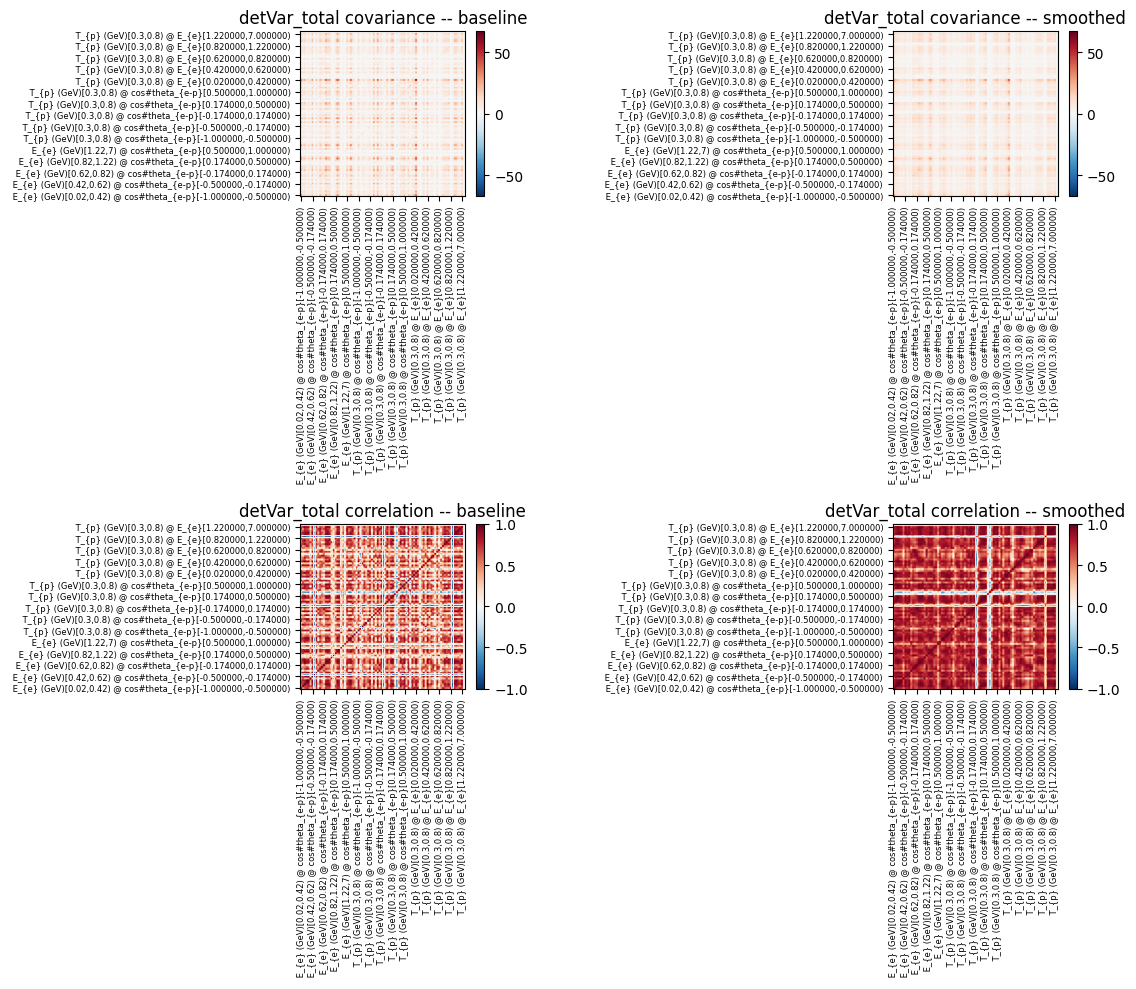

In [4]:
fig, axes = plot_comparison("detVar_total")
plt.show()

## Each individual DetVar

Uncomment the `savefig` line to export a PNG/PDF per systematic for the talk (adjust the path/format as needed).

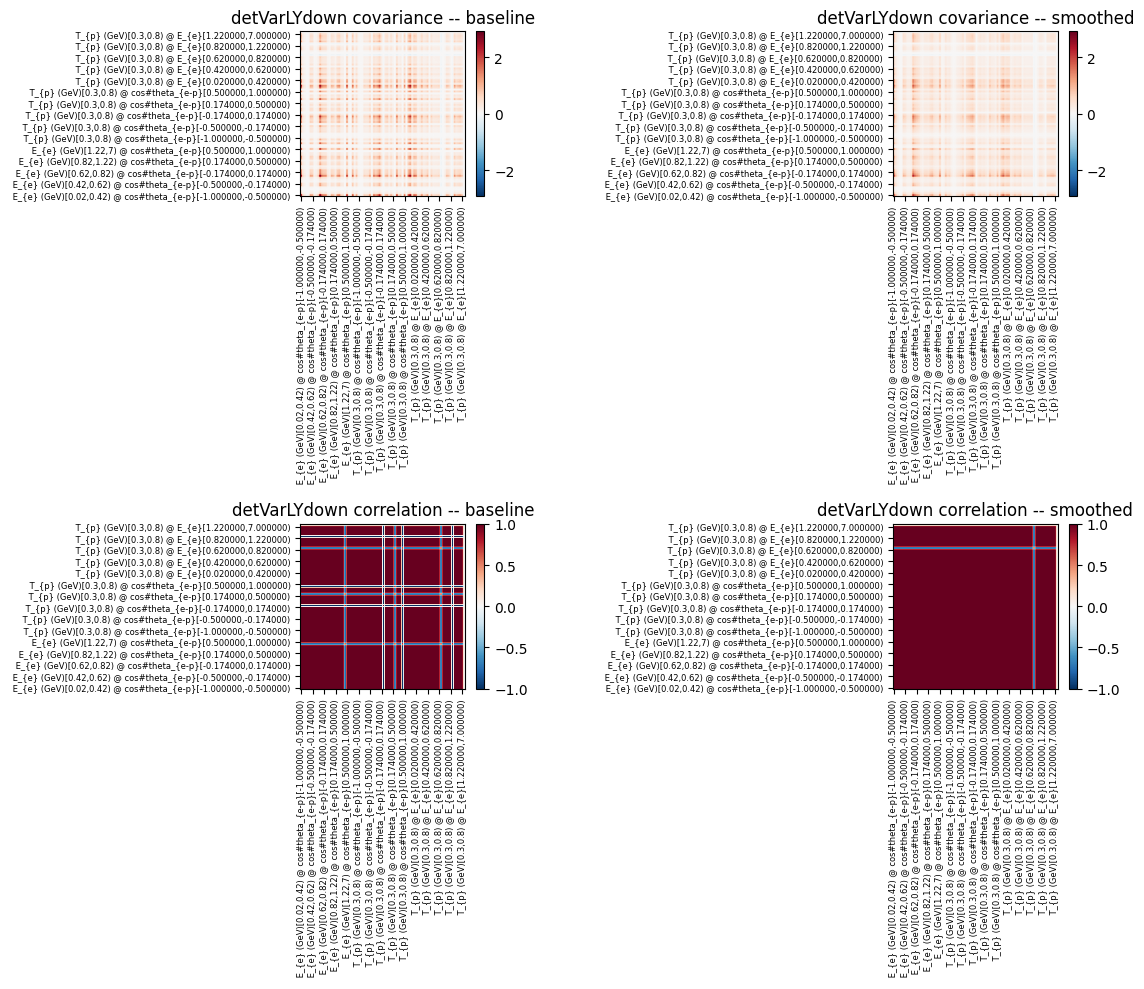

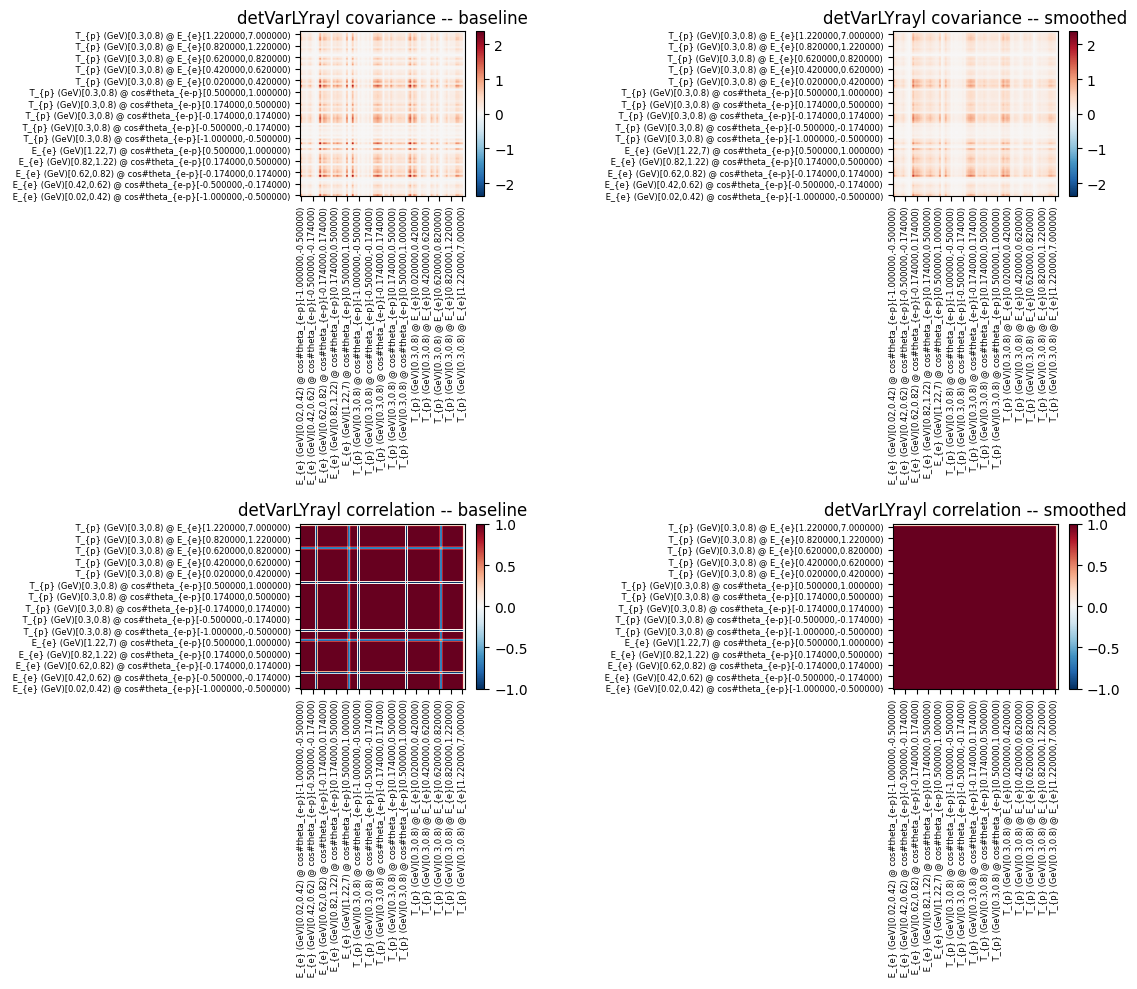

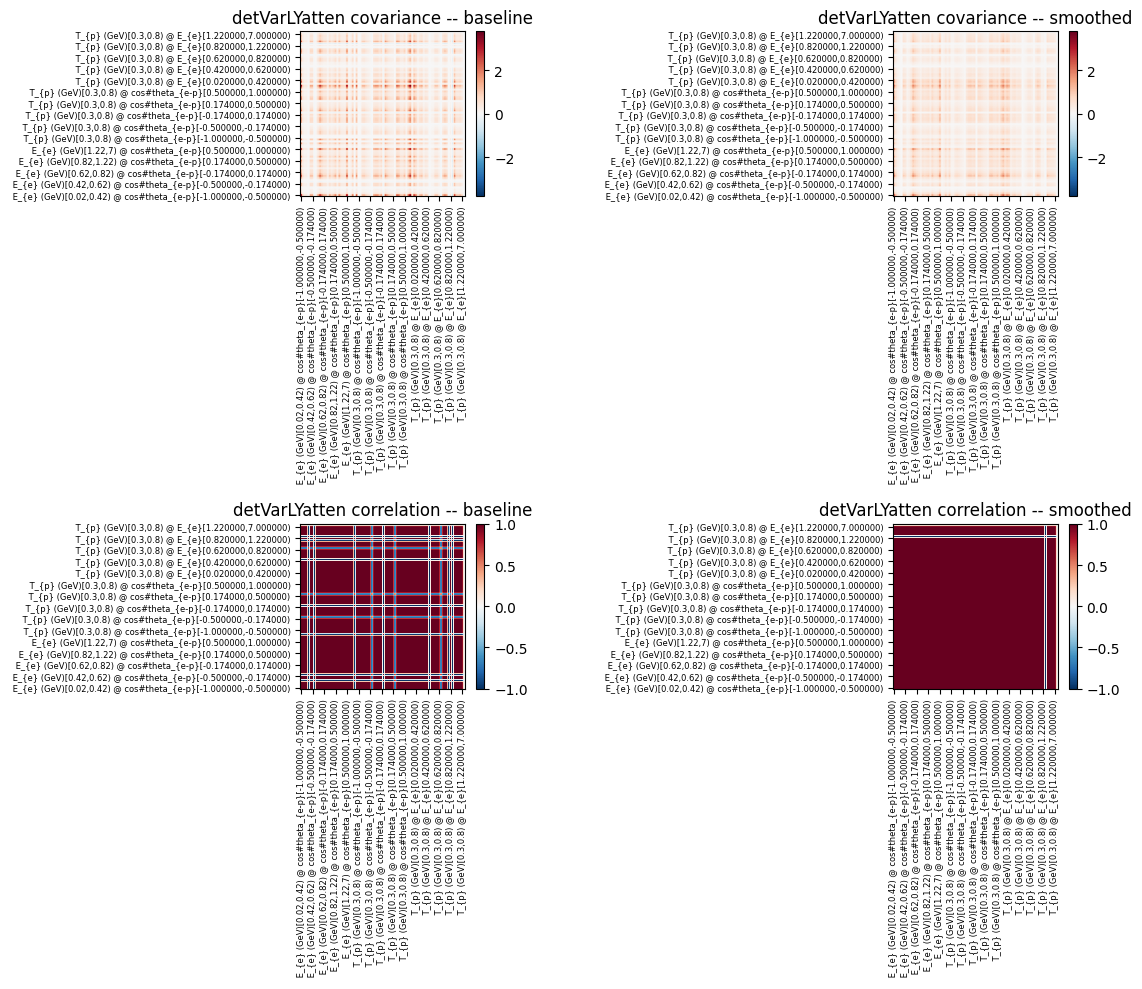

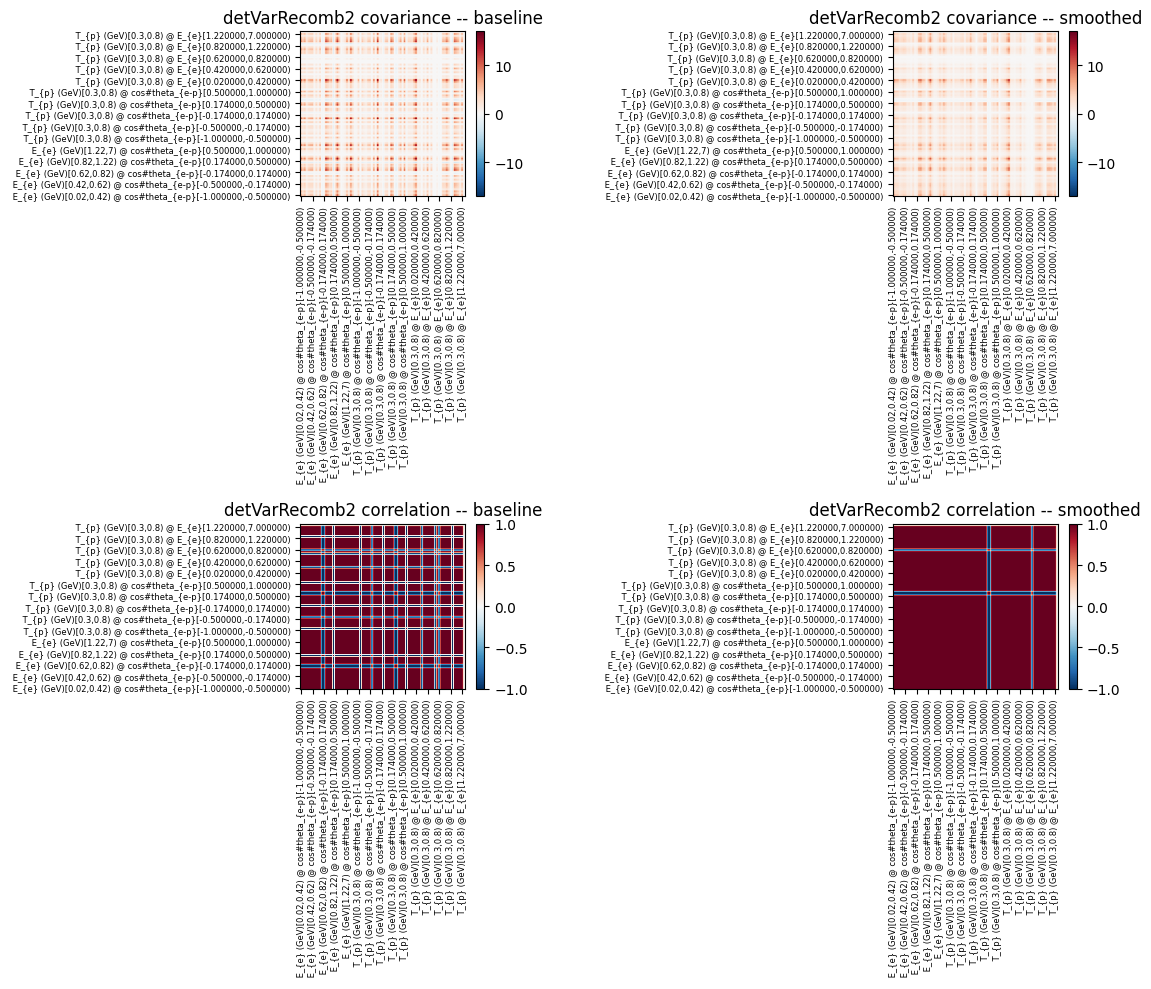

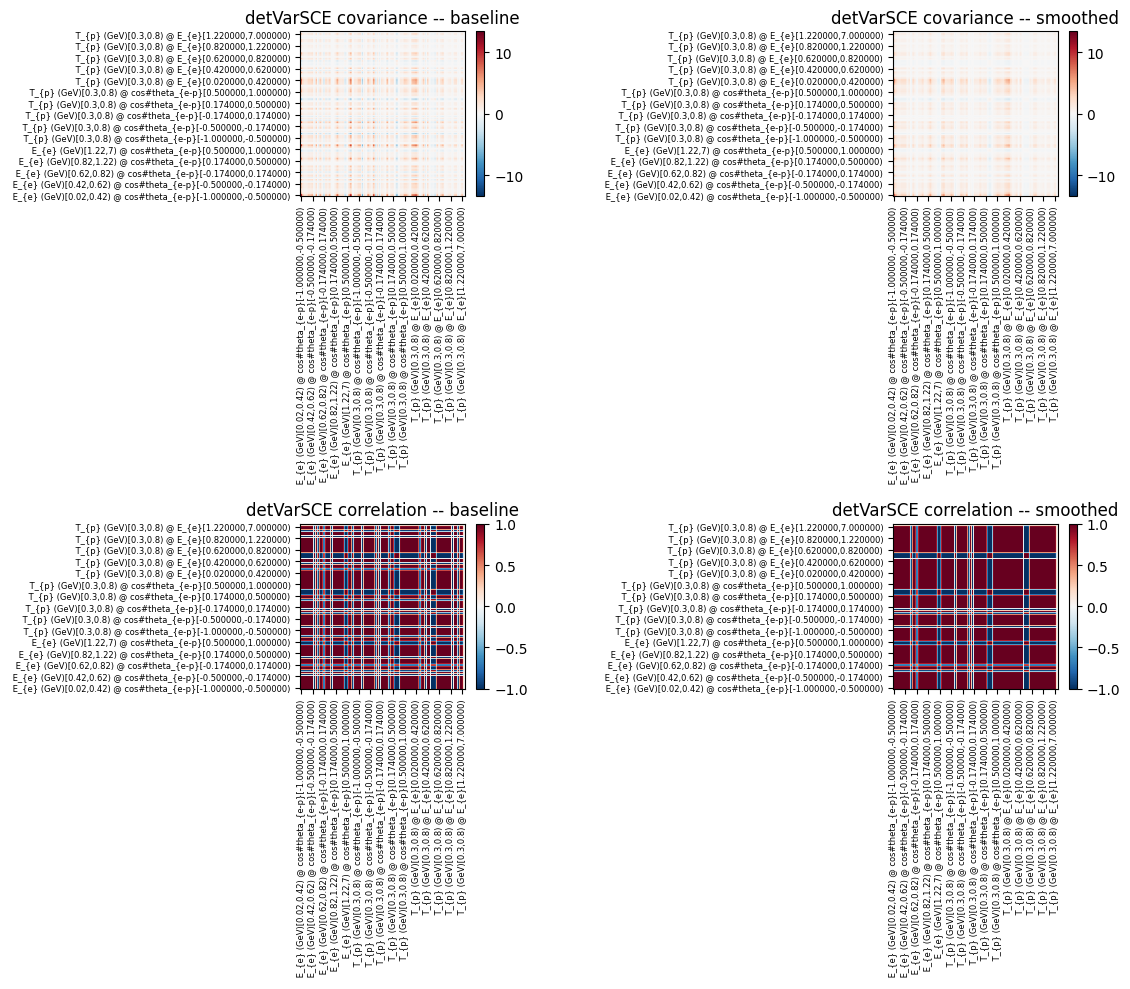

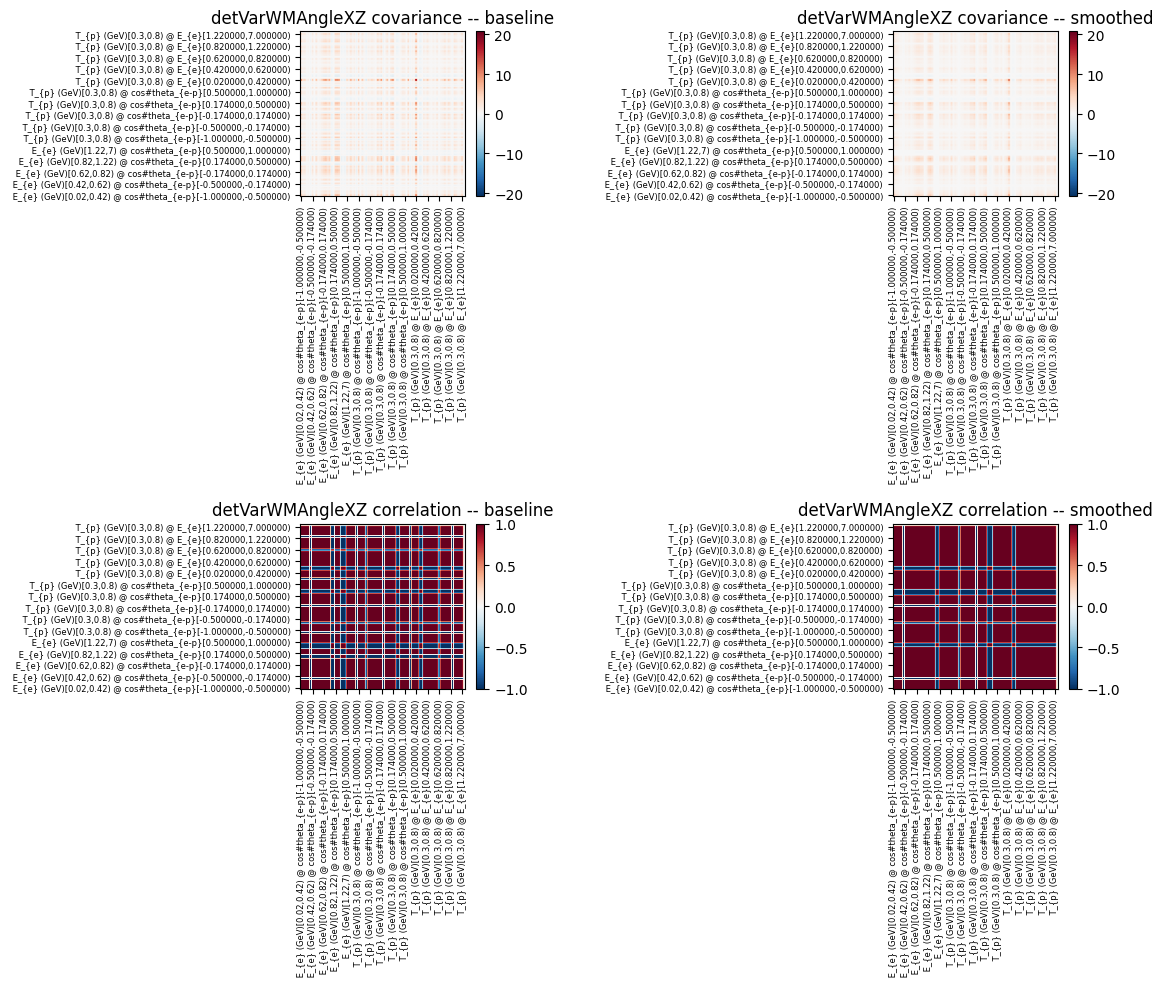

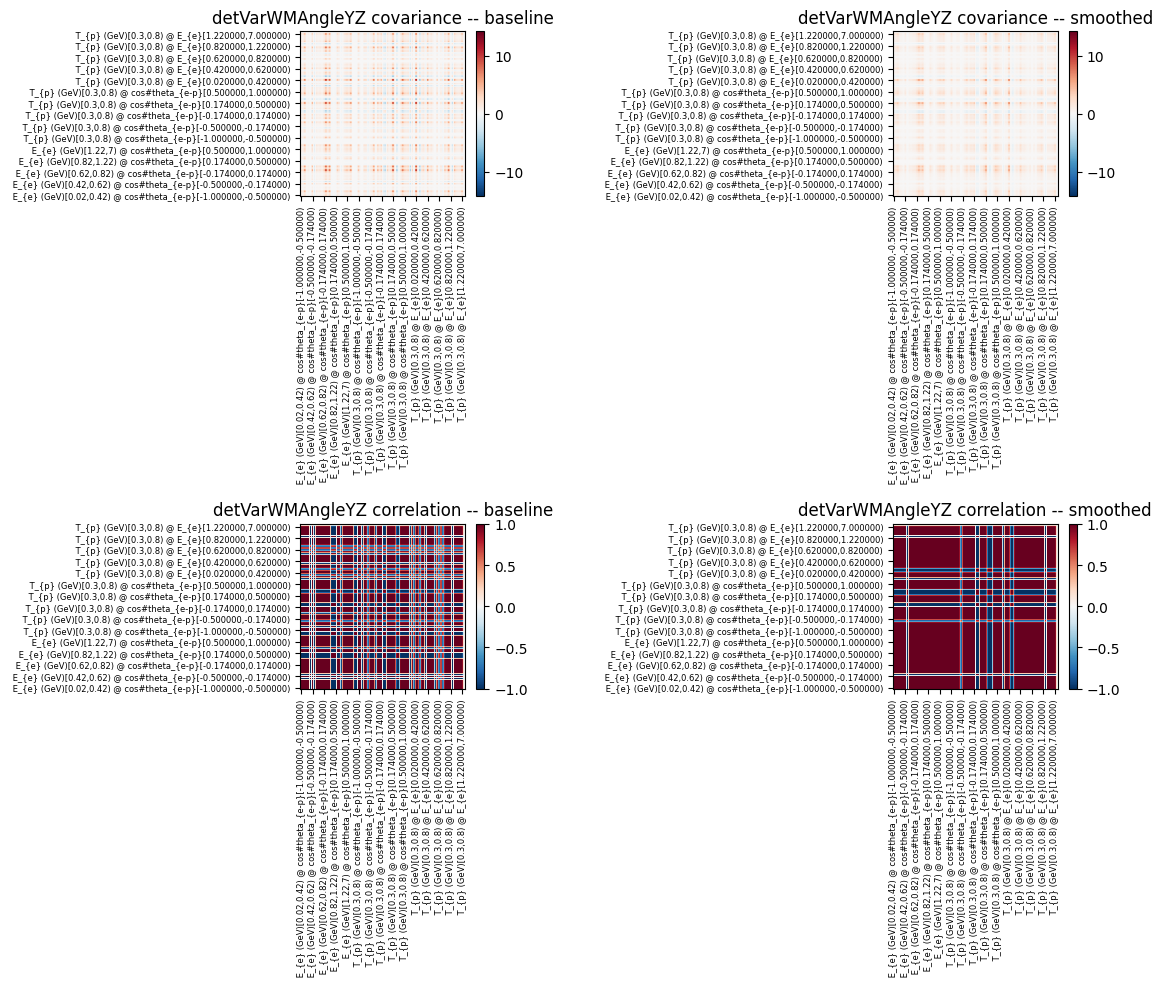

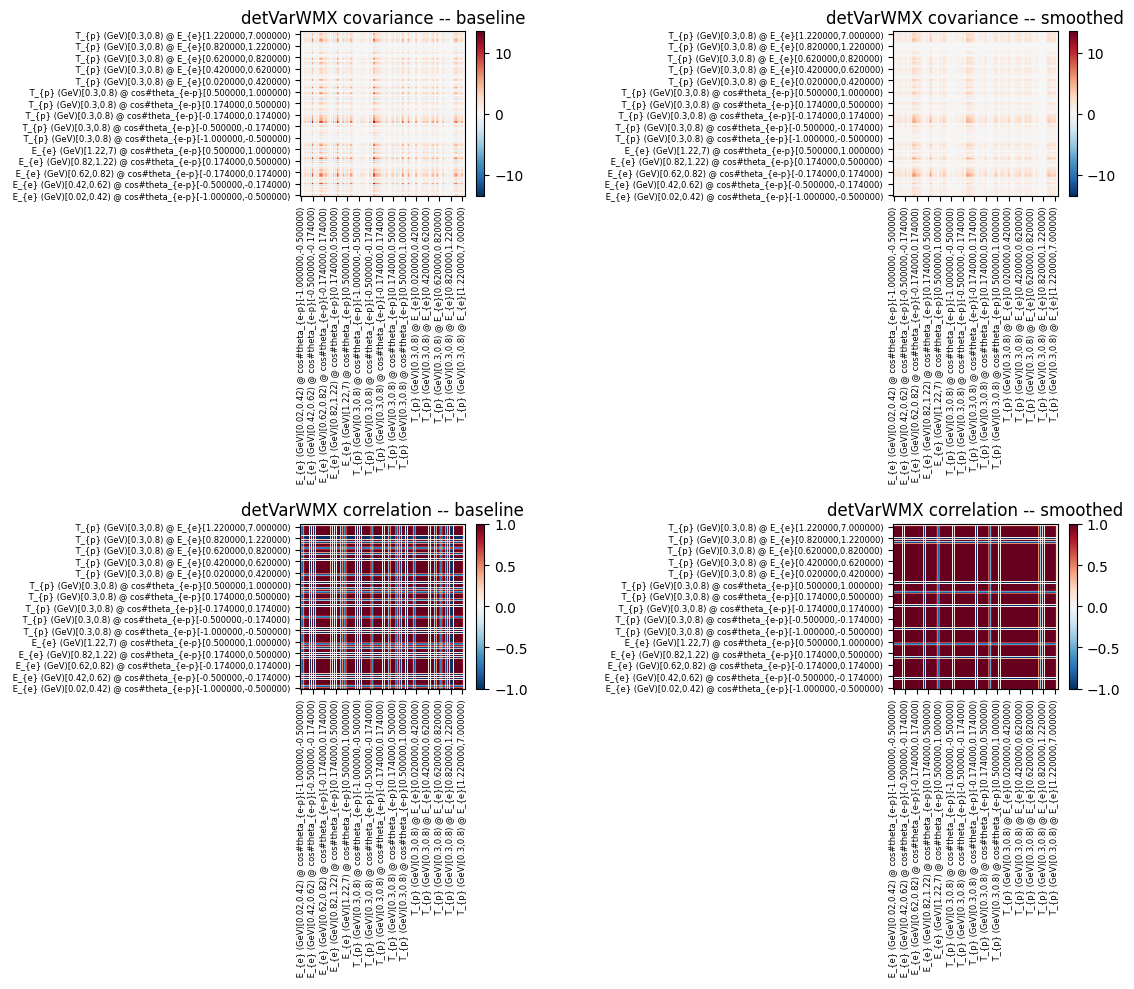

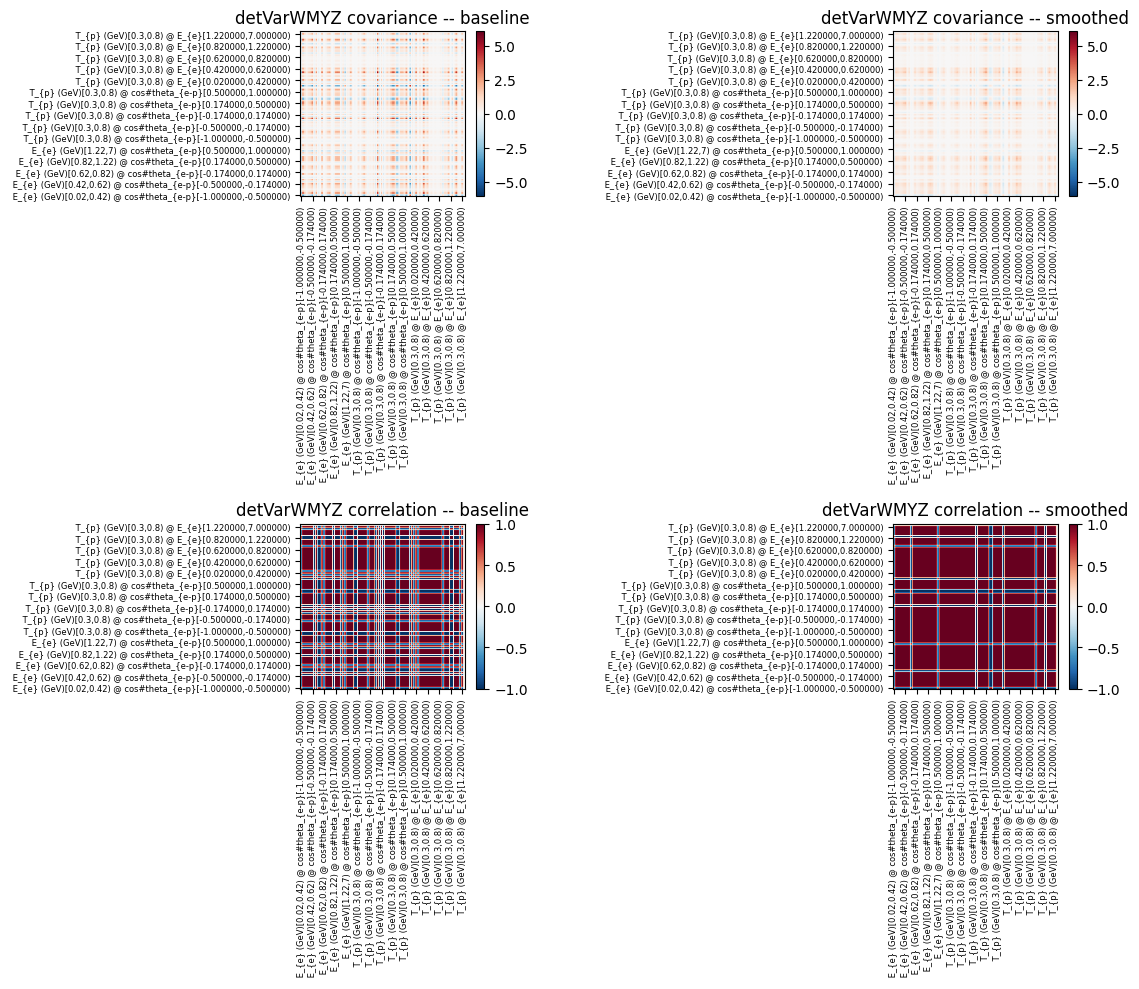

In [5]:
for name in systematics:
    if name == "detVar_total":
        continue  # already shown above
    fig, axes = plot_comparison(name)
    # fig.savefig(f"/exp/uboone/data/users/abarnard/analysis/detvar_covariance_matrices/{name}_comparison.png", dpi=200)
    plt.show()

## Correlation-only, side by side (talk-friendly single-row layout)

A leaner alternative to the full 2x2 grid above, if you just want to show the correlation structure changing under smoothing for a given systematic.

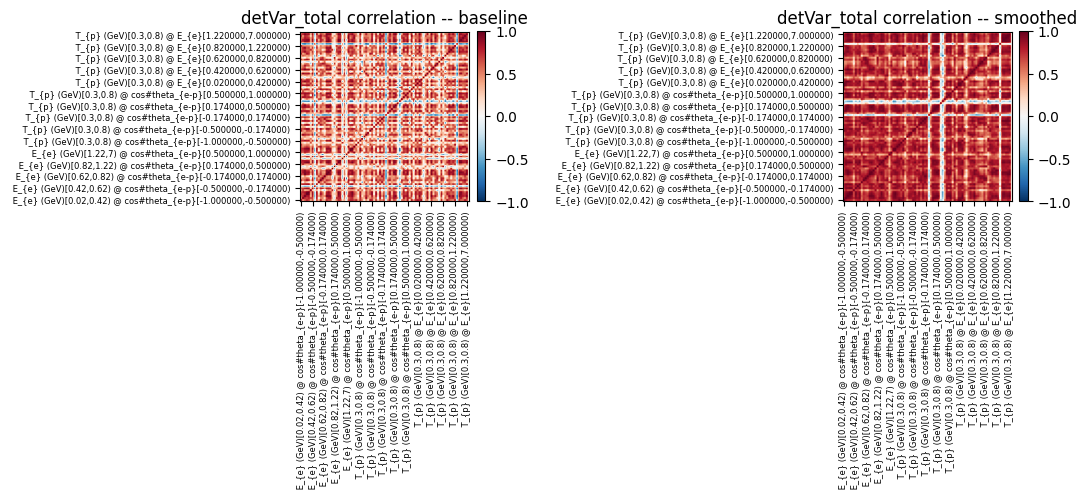

In [6]:
def plot_correlation_only(name, tick_every=6, figsize=(11, 5)):
    corr_before = f[f"{name}_corr_baseline"].values()
    corr_after  = f[f"{name}_corr_smoothed"].values()

    tick_pos = np.arange(0, len(bin_labels), tick_every)
    tick_lbl = [bin_labels[i] for i in tick_pos]

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    for ax, vals, title in (
        (axes[0], corr_before, f"{name} correlation -- baseline"),
        (axes[1], corr_after,  f"{name} correlation -- smoothed"),
    ):
        im = ax.imshow(vals, cmap="RdBu_r", vmin=-1., vmax=1., origin="lower")
        ax.set_title(title)
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_lbl, rotation=90, fontsize=6)
        ax.set_yticks(tick_pos)
        ax.set_yticklabels(tick_lbl, fontsize=6)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.tight_layout()
    return fig, axes

fig, axes = plot_correlation_only("detVar_total")
plt.show()

## By variable combination (angle-vs-T_p, angle-vs-E_e, E_e-vs-T_p)

The double-differential binning is actually three separate 2D blocks glued together into one 86-bin covariance matrix, plus one trailing background bin. Verified directly against the bin labels above:

| Block | Variables | Bin range | Size |
|---|---|---|---|
| 0 | opening angle vs. electron energy | 0-24 | 25 |
| 1 | opening angle vs. proton KE | 25-54 | 30 |
| 2 | electron energy vs. proton KE | 55-84 | 30 |
| - | background/other | 85 | 1 |

No new processing needed -- these are just contiguous sub-blocks of the full matrix we already loaded. `Slice`-based binning (from the C++ codebase) only defines the smoothing kernel's neighbor groups; the covariance/correlation matrix itself was never sliced in the first place.

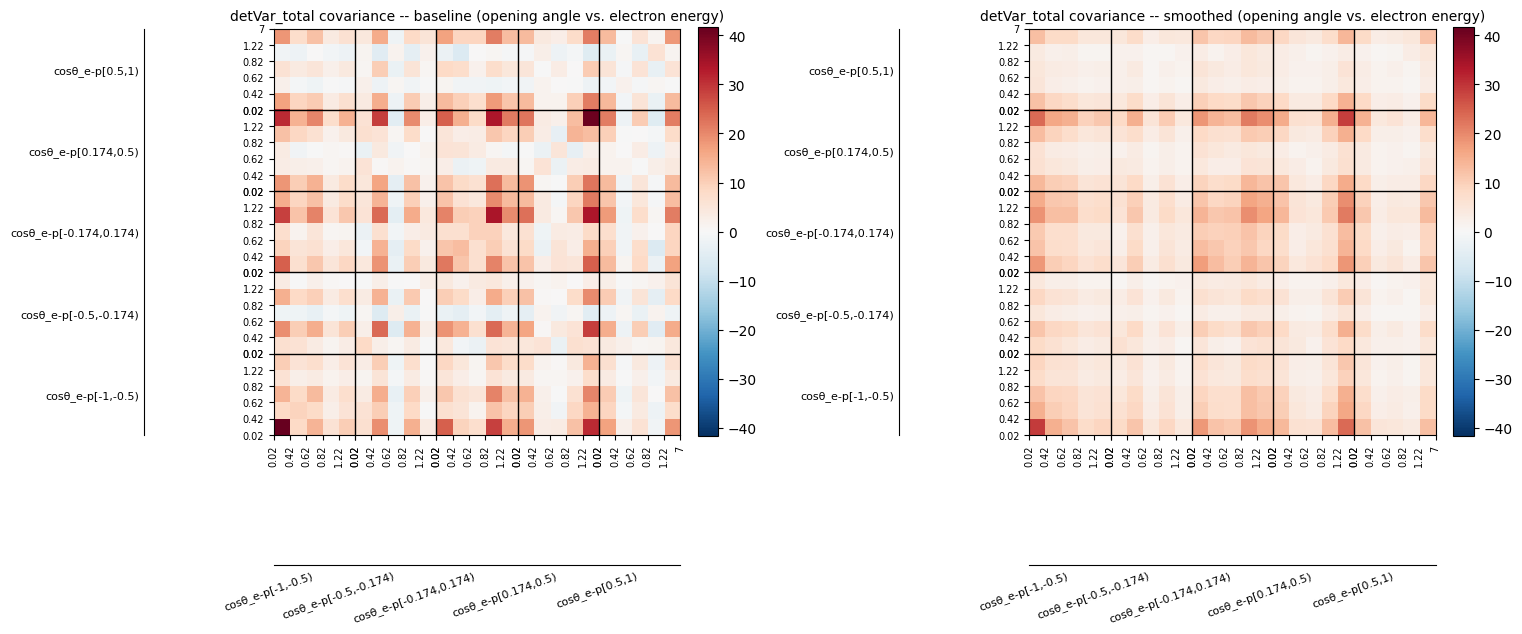

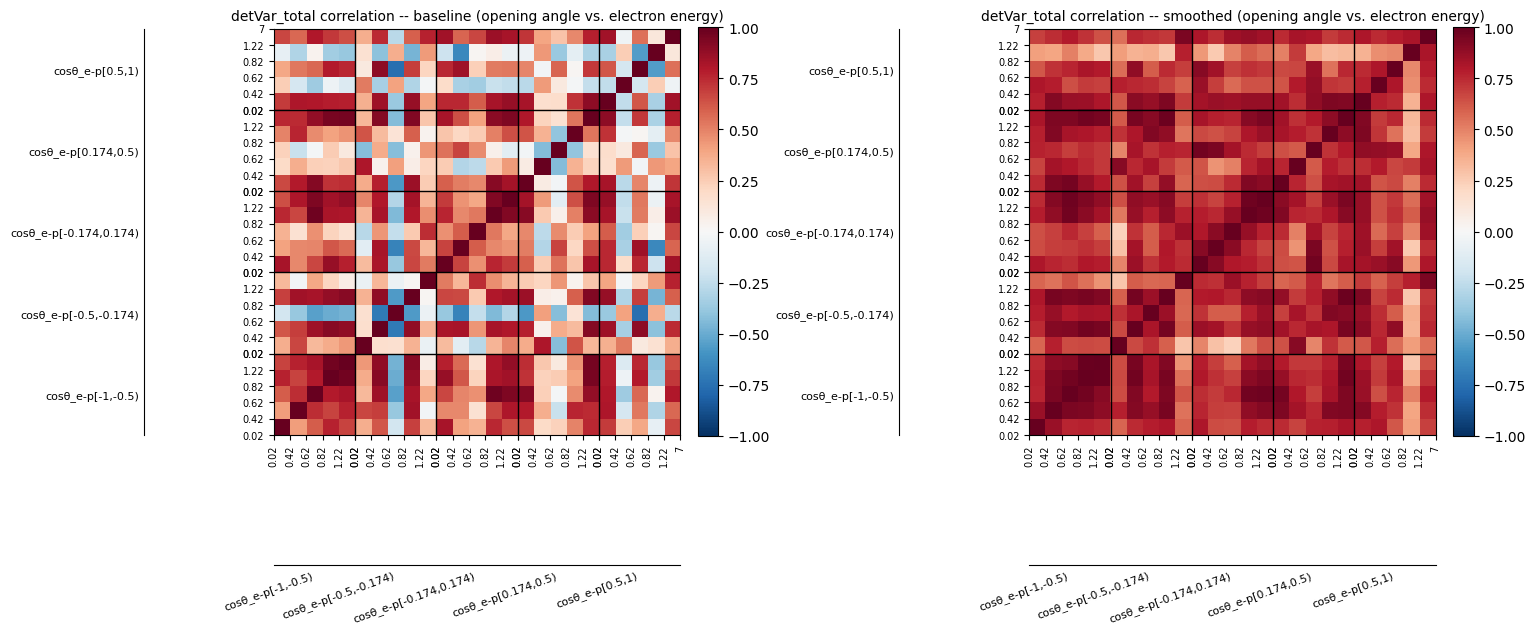

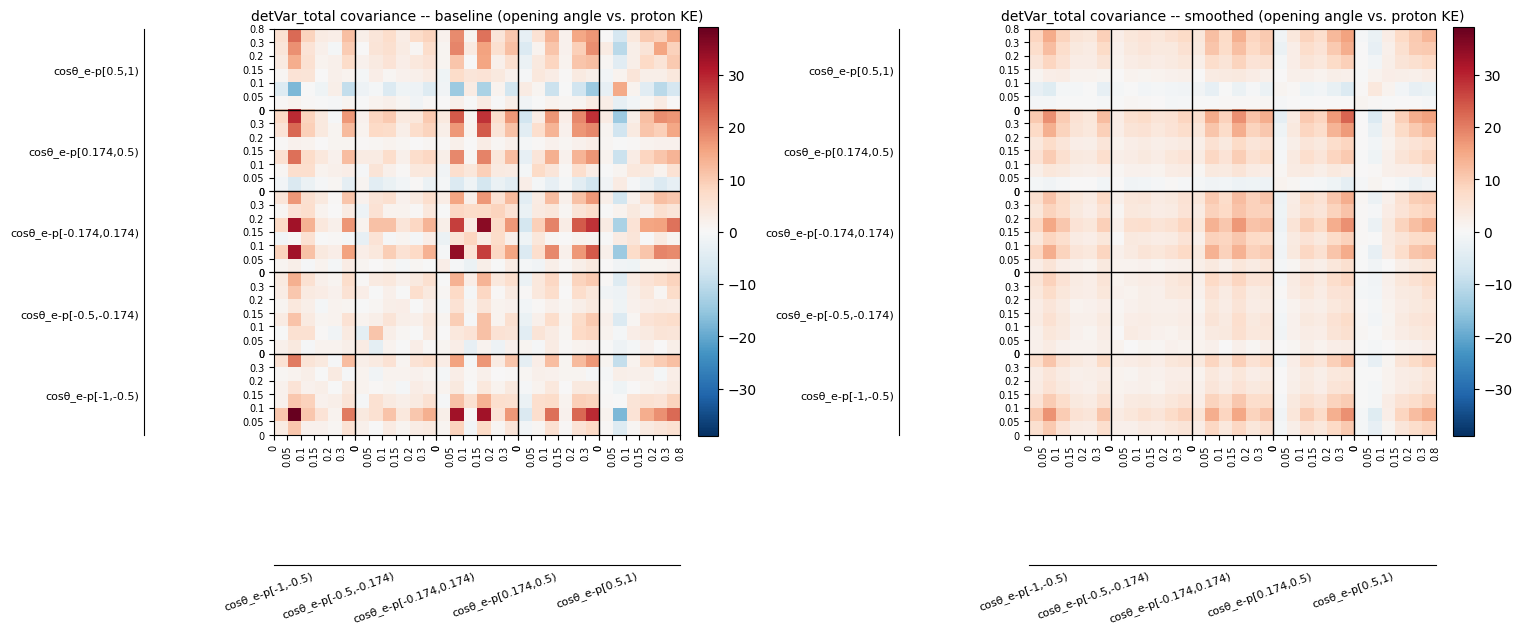

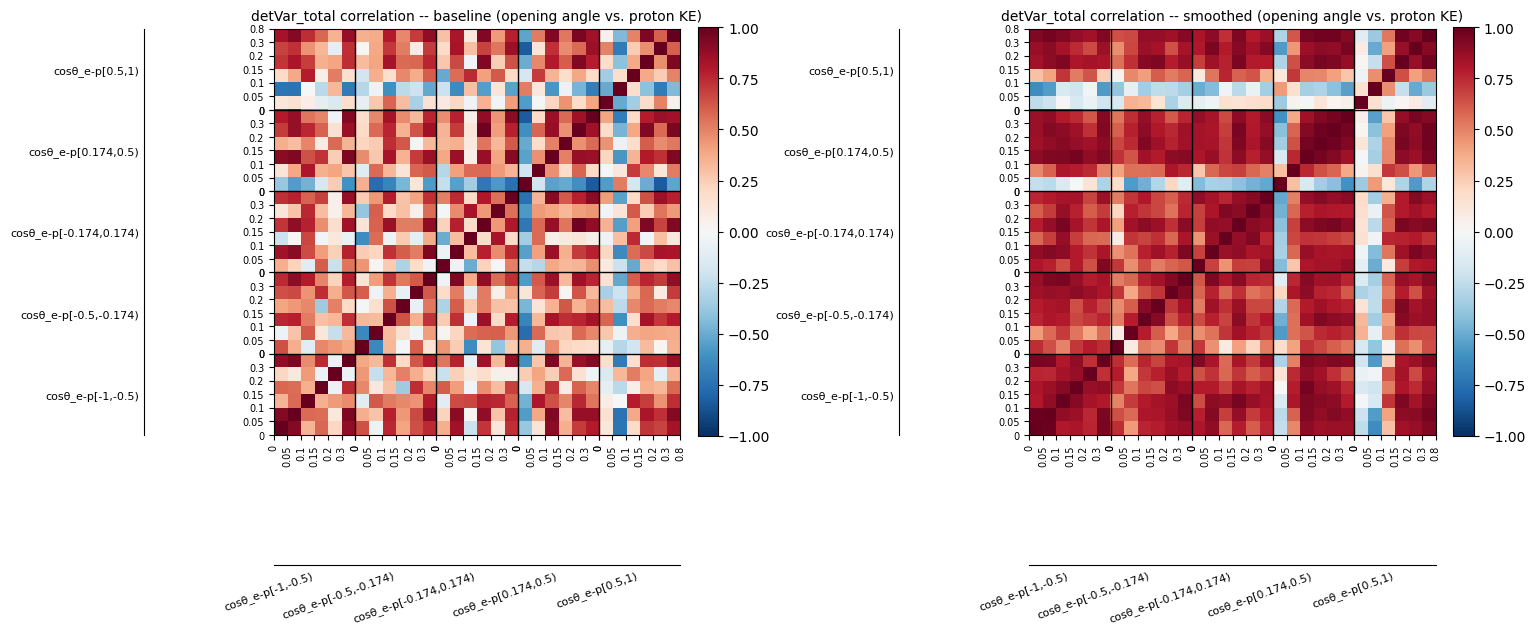

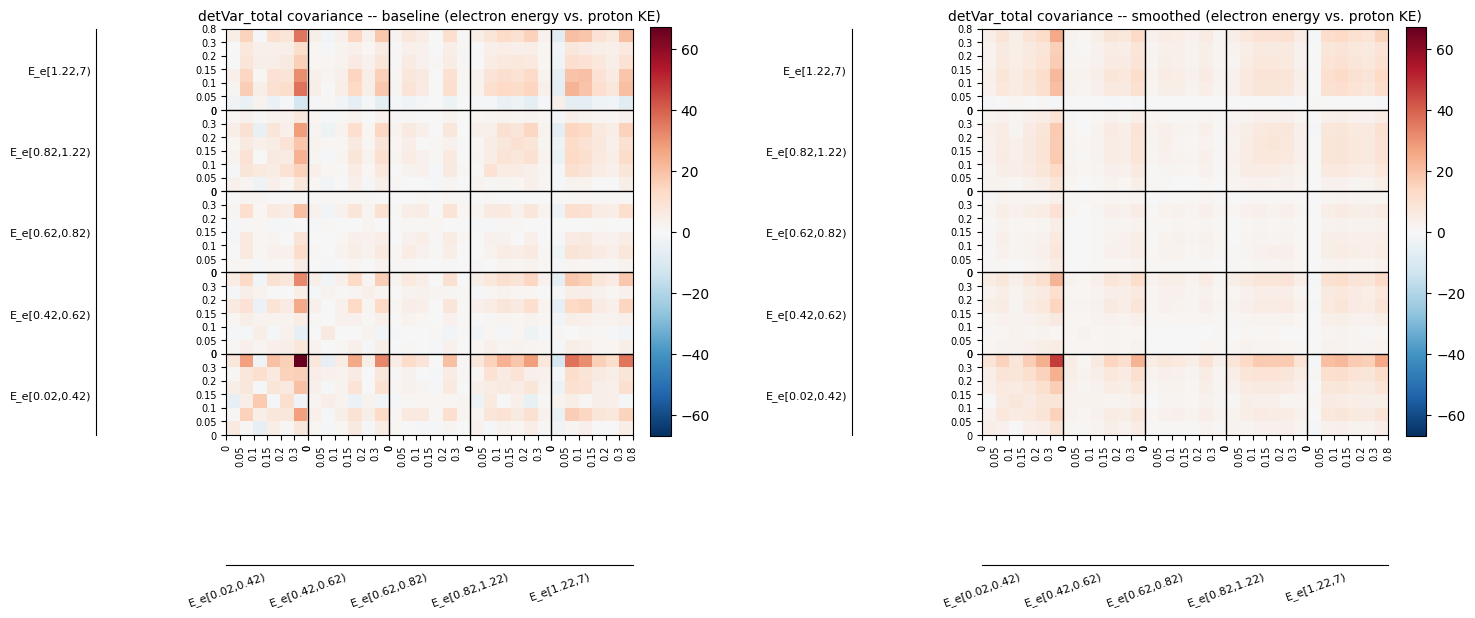

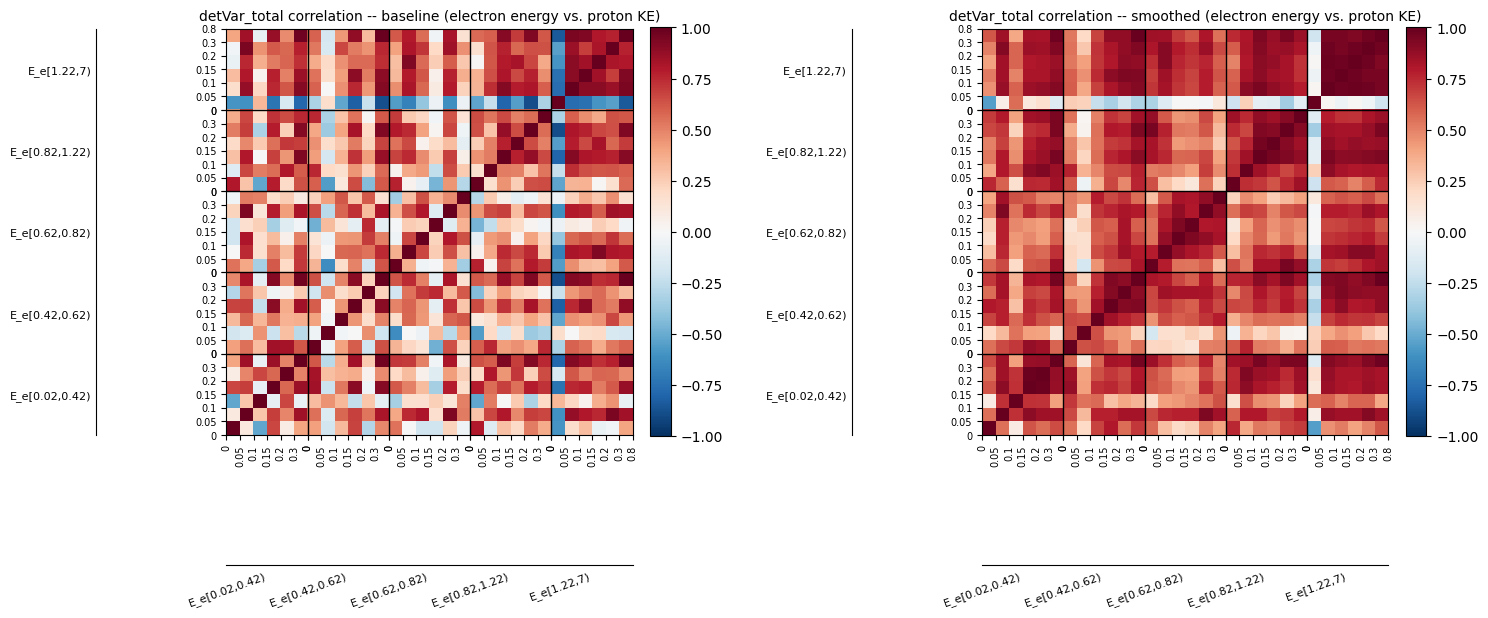

In [7]:
import re

VARIABLE_BLOCKS = {
    "angle_vs_Ee": (0, 25, "opening angle vs. electron energy"),
    "angle_vs_Tp": (25, 55, "opening angle vs. proton KE"),
    "Ee_vs_Tp":    (55, 85, "electron energy vs. proton KE"),
}


def clean_label(s):
    """ROOT TLatex ('#theta', 'T_{p}') doesn't render in matplotlib -- swap in
    unicode/plain equivalents, and trim needless decimal precision, so axis
    text actually displays cleanly."""
    s = s.strip()
    s = s.replace("#theta", "θ")
    s = re.sub(r"_\{([^}]*)\}", r"_\1", s)
    # Trim "-0.500000" -> "-0.5", "1.220000" -> "1.22", etc.
    s = re.sub(r"(-?\d+\.\d*?)0+(?=[,)])", lambda m: m.group(1).rstrip("."), s)
    return s


def split_label(s):
    """Each bin label is 'inner-variable range @ outer-variable range' --
    split those apart so they can be shown as two separate tick tiers."""
    inner, outer = clean_label(s).split(" @ ")
    return inner, outer


def find_group_boundaries(outer_labels):
    """Index positions where the outer (grouping) variable's value changes."""
    boundaries = [0]
    for i in range(1, len(outer_labels)):
        if outer_labels[i] != outer_labels[i - 1]:
            boundaries.append(i)
    boundaries.append(len(outer_labels))
    return boundaries


def format_edge(v):
    """Short display form for a bin-edge value: '0.5' not '0.500000', '0' not '0.0'."""
    return str(int(v)) if v == int(v) else f"{v:g}"


def bin_edges_from_ranges(range_labels):
    """Given per-bin '[lo,hi)' range strings (contiguous, already cleaned),
    return the N+1 boundary values -- one per bin edge, including the very
    first and last -- instead of one range string per bin."""
    edges = []
    for i, s in enumerate(range_labels):
        lo, hi = s.strip("[)").split(",")
        if i == 0:
            edges.append(float(lo))
        edges.append(float(hi))
    return edges


def _draw_block_panel(ax, vals, title, vmin, vmax, inner_short, boundaries,
                       group_centers, group_texts):
    im = ax.imshow(vals, cmap="RdBu_r", vmin=vmin, vmax=vmax, origin="lower")
    ax.set_title(title, fontsize=10)

    # Numbers at the bin edges (not a range label centered on each bin). The
    # inner variable resets at each outer-group boundary (e.g. T_p restarts
    # at 0 for every new cos(theta) group), so edges have to be computed
    # per group rather than as one sequence across the whole block.
    edge_pos, edge_lbl = [], []
    for g in range(len(boundaries) - 1):
        b_lo, b_hi = boundaries[g], boundaries[g + 1]
        edges = bin_edges_from_ranges(inner_short[b_lo:b_hi])
        edge_pos.extend(np.arange(len(edges)) - 0.5 + b_lo)
        edge_lbl.extend(format_edge(v) for v in edges)
    ax.set_xticks(edge_pos)
    ax.set_xticklabels(edge_lbl, rotation=90, fontsize=7)
    ax.set_yticks(edge_pos)
    ax.set_yticklabels(edge_lbl, fontsize=7)

    # Gridlines at each group boundary -- makes the block-diagonal structure
    # visible at a glance, without needing to read any labels at all.
    for b in boundaries[1:-1]:
        ax.axvline(b - 0.5, color="black", linewidth=1.0)
        ax.axhline(b - 0.5, color="black", linewidth=1.0)

    # One larger label per group (the slow-varying "outer" variable), shown
    # once via a secondary axis instead of being repeated on every bin.
    secx = ax.secondary_xaxis(-0.32)
    secx.set_xticks(group_centers)
    secx.set_xticklabels(group_texts, fontsize=8, rotation=20, ha="right")
    secx.tick_params(length=0)

    secy = ax.secondary_yaxis(-0.32)
    secy.set_yticks(group_centers)
    secy.set_yticklabels(group_texts, fontsize=8)
    secy.tick_params(length=0)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


def plot_block_comparison(name, block_key, kind="covariance", figsize=(15, 8)):
    """Baseline vs. smoothed, side by side, for one variable-combination
    block. kind is 'covariance' or 'correlation'. Two-tier axis labels: a
    small numeric tick per bin edge for the inner (fast-varying) variable,
    one larger label per group for the outer (slow-varying) variable, and
    gridlines at each group boundary -- much more readable than repeating
    the full compound label on every bin.
    """
    lo, hi, desc = VARIABLE_BLOCKS[block_key]

    block_raw_labels = bin_labels[lo:hi]
    inner_labels, outer_labels = zip(*[split_label(s) for s in block_raw_labels])
    inner_short = [re.sub(r"^[A-Za-z_]+ \(GeV\)", "", s) for s in inner_labels]

    boundaries = find_group_boundaries(outer_labels)
    group_centers = [(boundaries[i] + boundaries[i + 1] - 1) / 2
                      for i in range(len(boundaries) - 1)]
    group_texts = [outer_labels[boundaries[i]] for i in range(len(boundaries) - 1)]

    key = "cov" if kind == "covariance" else "corr"
    before = f[f"{name}_{key}_baseline"].values()[lo:hi, lo:hi]
    after  = f[f"{name}_{key}_smoothed"].values()[lo:hi, lo:hi]

    if kind == "covariance":
        scale = max(np.abs(before).max(), np.abs(after).max()) or 1.
        vmin, vmax = -scale, scale
    else:
        vmin, vmax = -1., 1.

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    _draw_block_panel(axes[0], before, f"{name} {kind} -- baseline ({desc})",
                       vmin, vmax, inner_short, boundaries, group_centers, group_texts)
    _draw_block_panel(axes[1], after, f"{name} {kind} -- smoothed ({desc})",
                       vmin, vmax, inner_short, boundaries, group_centers, group_texts)

    fig.subplots_adjust(bottom=0.05, left=0.1, wspace=0.7)
    return fig, axes


for block_key in VARIABLE_BLOCKS:
    fig, axes = plot_block_comparison("detVar_total", block_key, kind="covariance")
    plt.show()
    fig, axes = plot_block_comparison("detVar_total", block_key, kind="correlation")
    plt.show()

## Fractional uncertainty (diagonal), each DetVar, baseline vs. smoothed

For your colleague's question: this needed one addition to the ROOT file that wasn't there before -- the actual predicted event rate (`reco_mc_plus_ext_prediction`, built exactly as `Slice_Plots.C` does: EXT + CV MC, never touched by smoothing). Covariance/correlation alone aren't enough for a *fractional* uncertainty; you need that prediction as the denominator. `bin/DetVarCovarianceComparison` now writes it out too, and the file in `/exp/uboone/data/users/abarnard/analysis/detvar_covariance_matrices/` has already been regenerated with it.

Fractional uncertainty per bin = sqrt(covariance diagonal) / prediction. Bin 85 (the background/catch-all bin) has zero prediction and is masked out rather than plotted as a divide-by-zero spike.

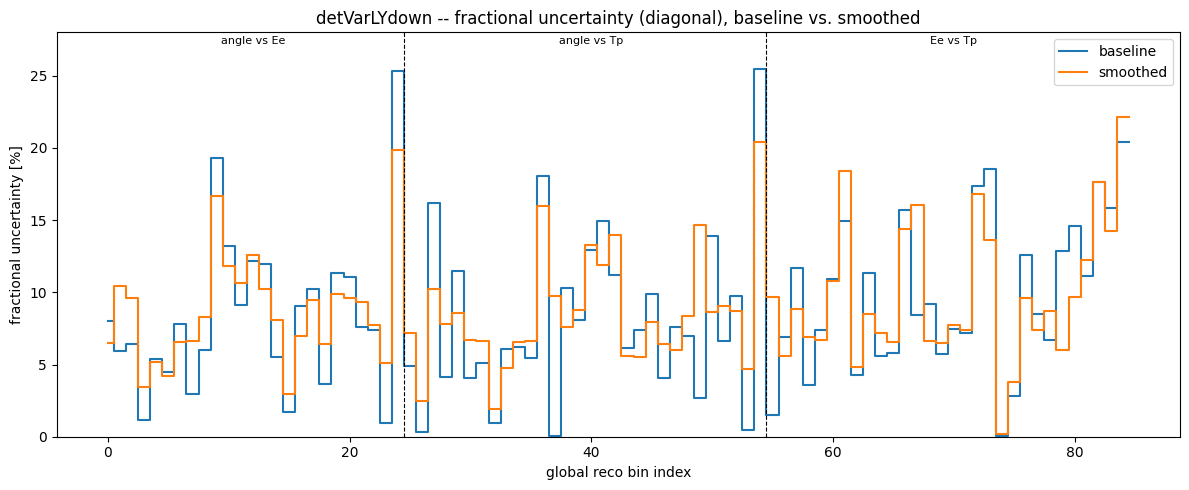

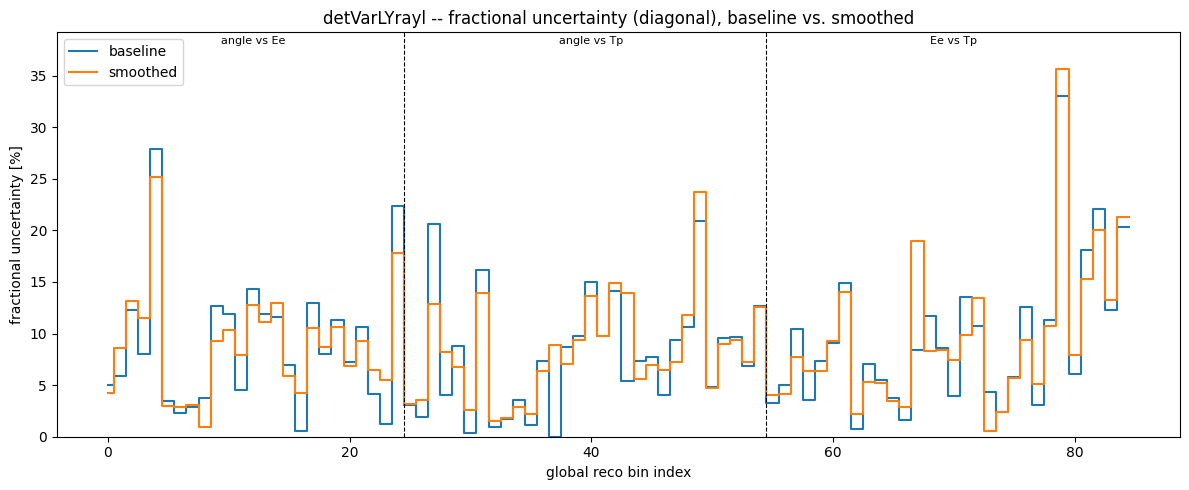

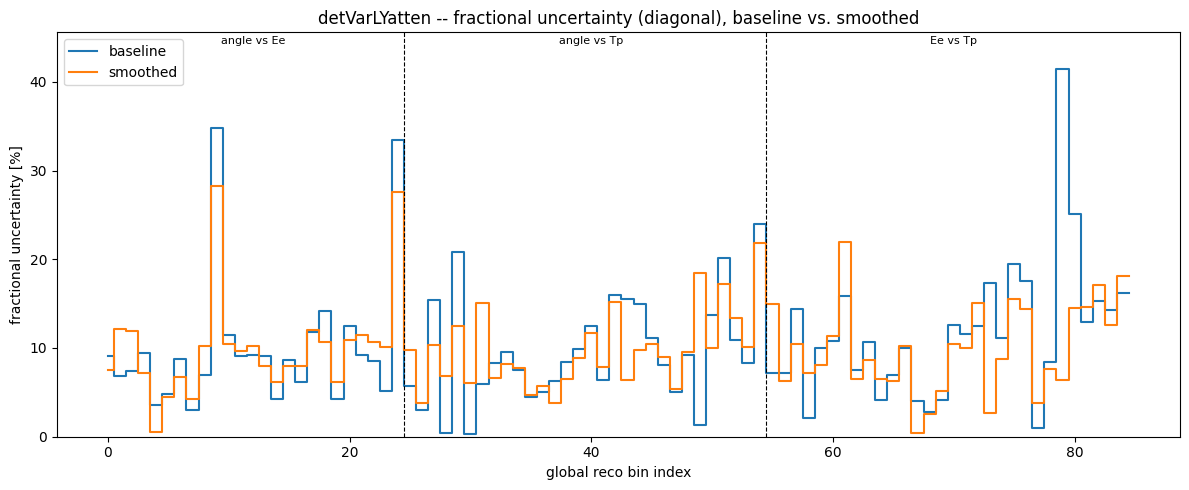

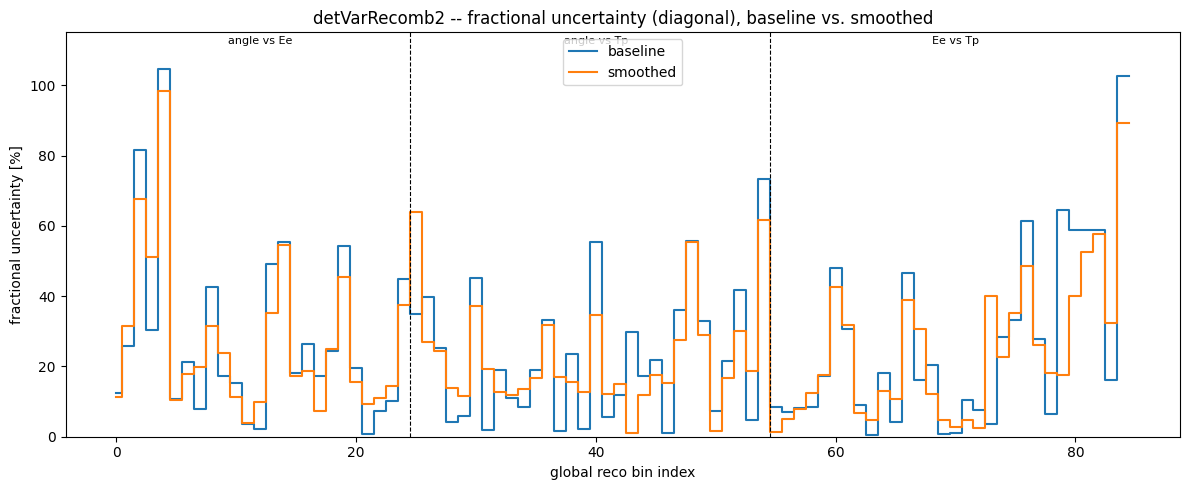

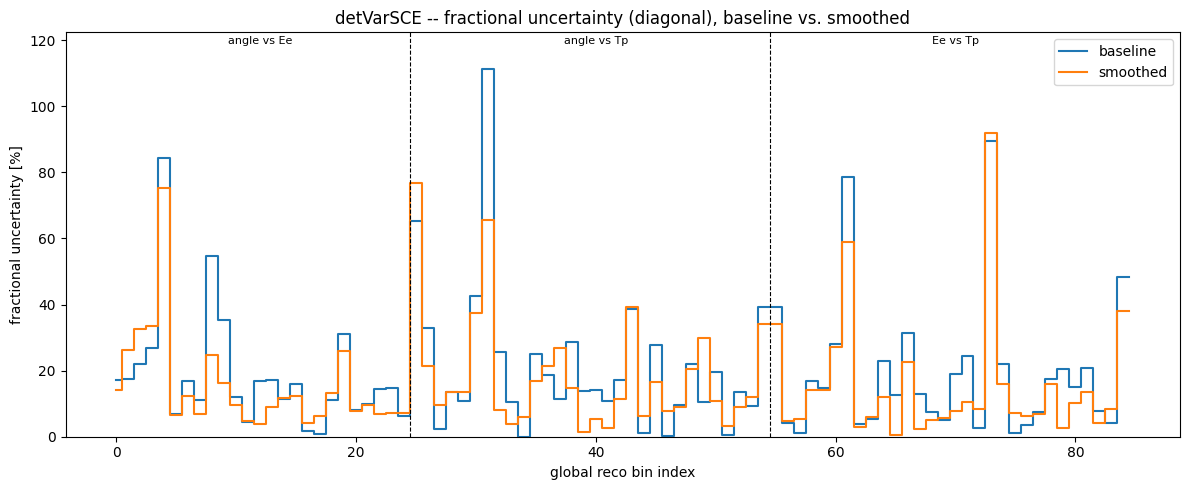

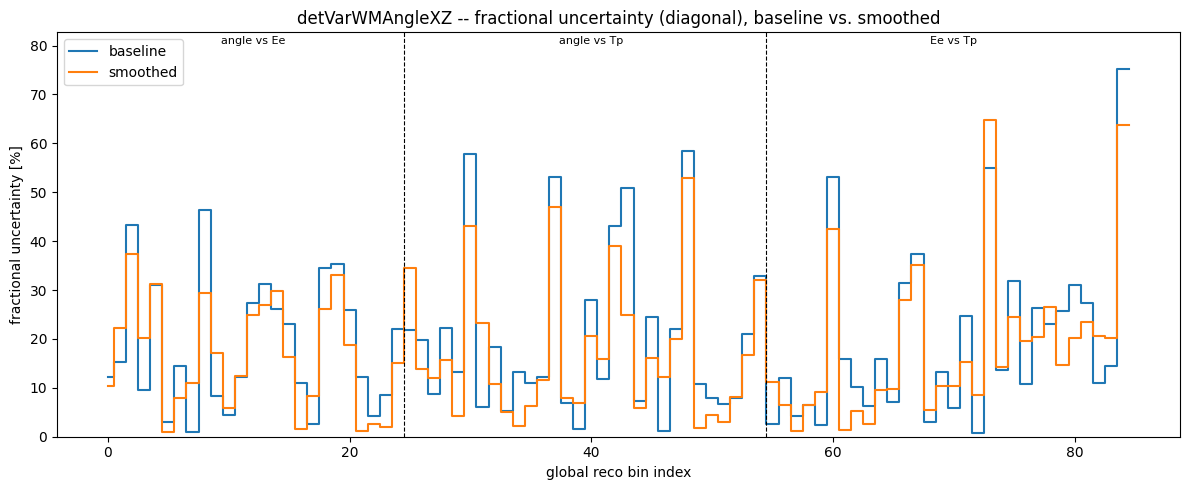

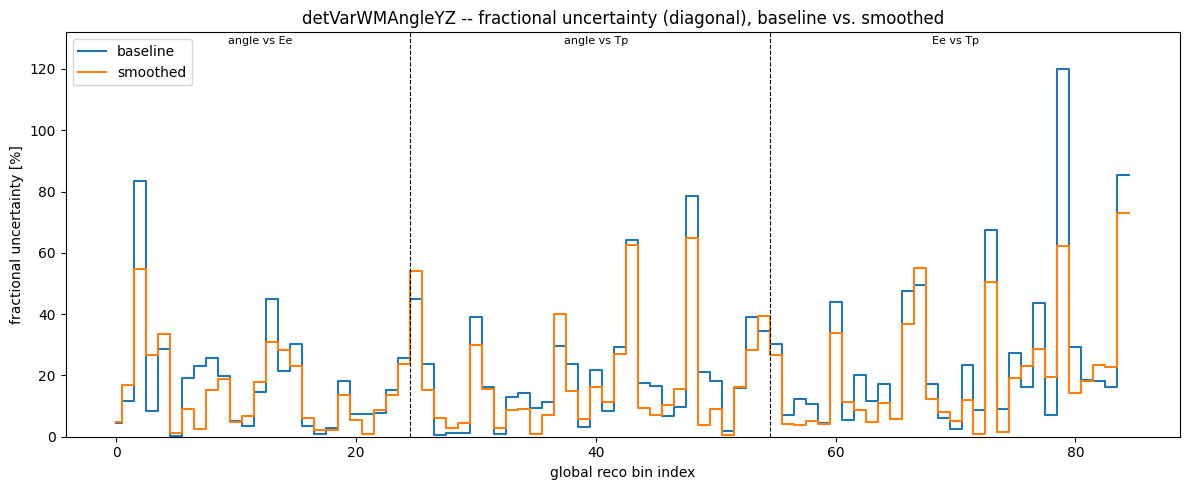

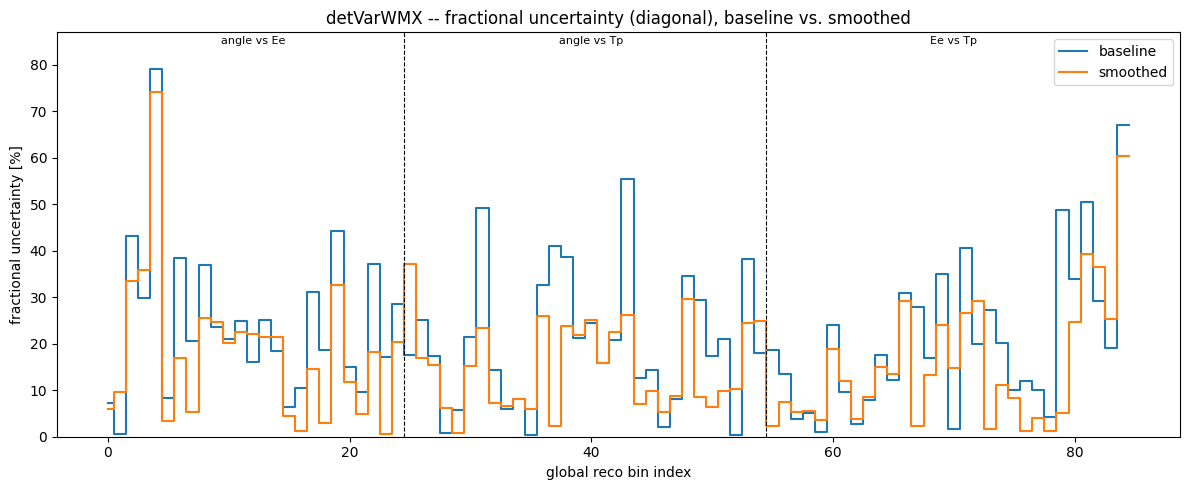

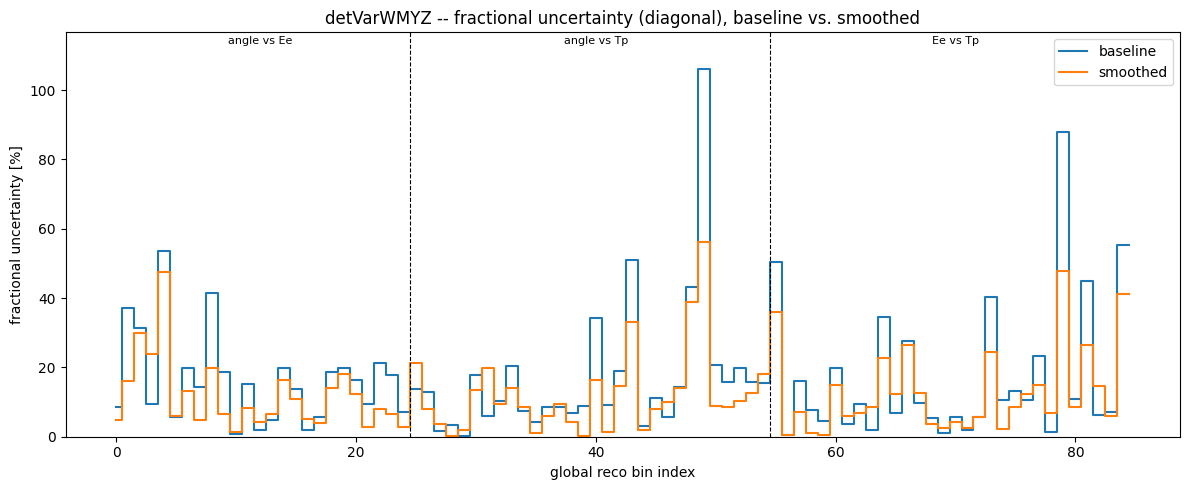

In [8]:
pred = f["reco_mc_plus_ext_prediction"].values()
pred_safe = np.where(pred > 0, pred, np.nan)  # bin 85: zero prediction, mask instead of dividing by zero


def plot_fractional_uncertainty(name, figsize=(12, 5)):
    cov_before = f[f"{name}_cov_baseline"].values()
    cov_after  = f[f"{name}_cov_smoothed"].values()
    frac_before = np.sqrt(np.clip(np.diag(cov_before), 0, None)) / pred_safe
    frac_after  = np.sqrt(np.clip(np.diag(cov_after), 0, None)) / pred_safe

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(pred))
    ax.step(x, frac_before * 100, where="mid", label="baseline", color="tab:blue")
    ax.step(x, frac_after * 100, where="mid", label="smoothed", color="tab:orange")

    # Block boundaries, same three variable-combination blocks as above
    for b in (25, 55):
        ax.axvline(b - 0.5, color="black", linewidth=0.8, linestyle="--")
    ymax = np.nanmax([frac_before, frac_after]) * 100 * 1.1
    for c, txt in ((12, "angle vs Ee"), (40, "angle vs Tp"), (70, "Ee vs Tp")):
        ax.text(c, ymax * 0.97, txt, ha="center", fontsize=8)

    ax.set_ylim(0, ymax)
    ax.set_xlabel("global reco bin index")
    ax.set_ylabel("fractional uncertainty [%]")
    ax.set_title(f"{name} -- fractional uncertainty (diagonal), baseline vs. smoothed")
    ax.legend()
    fig.tight_layout()
    return fig, ax


for name in systematics:
    if name == "detVar_total":
        continue
    fig, ax = plot_fractional_uncertainty(name)
    plt.show()

## Deep dive: one slice (E_e, cos θ_e-p in [-0.174, 0.174))

Everything above for a single slice, all four views together: bins 10-14, verified directly against the bin labels. This needed two more additions to the ROOT file that weren't there before:

- All 19 systematic types from `systcalc_numi.conf` (previously only the 10 DetVar-related ones were written) -- smoothing only ever touches DetVar-type covariances internally, so baseline == smoothed for the others; that's expected, not a bug.
- The raw CV + 9 individual DetVar per-bin values (unsmoothed and smoothed), not just their derived covariance -- mirrors `Slice_Plots.C`'s c4 canvas exactly.

`bin/DetVarCovarianceComparison` writes both now; the file has already been regenerated. Everything below is plain functions over plain arrays, so restyle freely -- colors, fonts, layout, whatever you need for your slides.

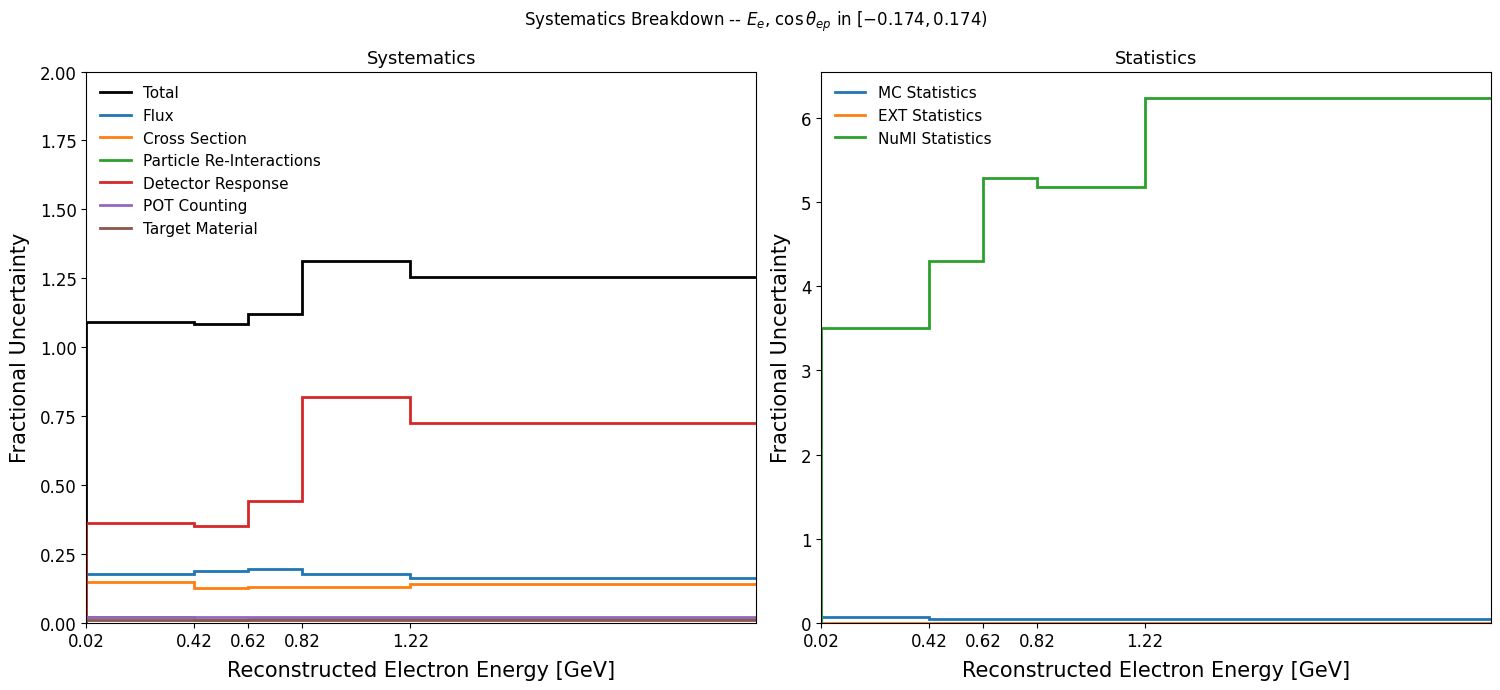

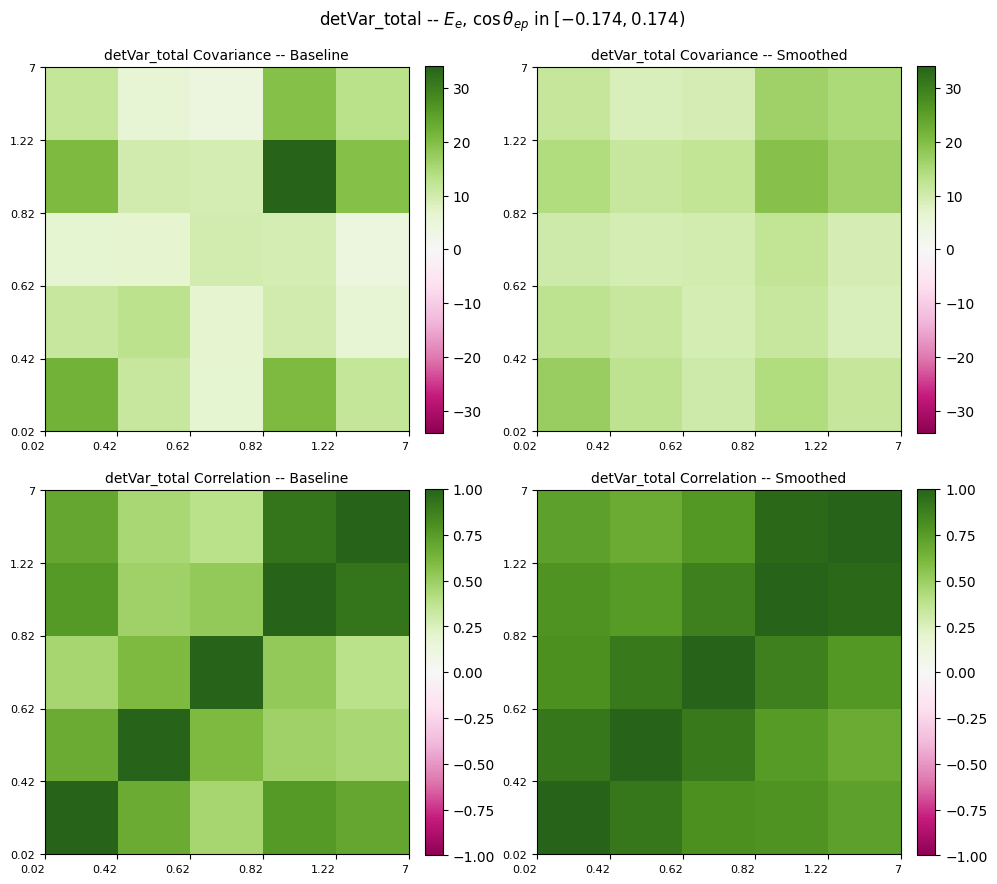

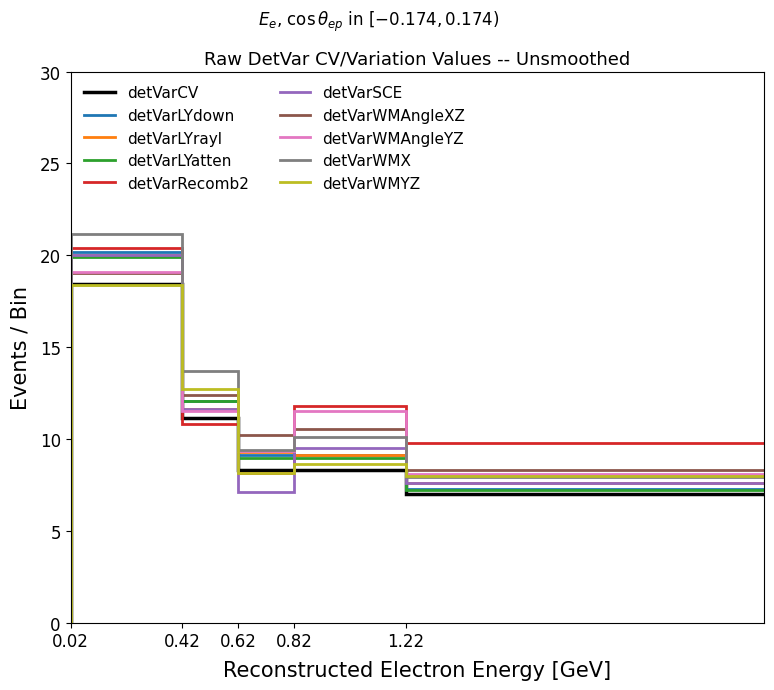

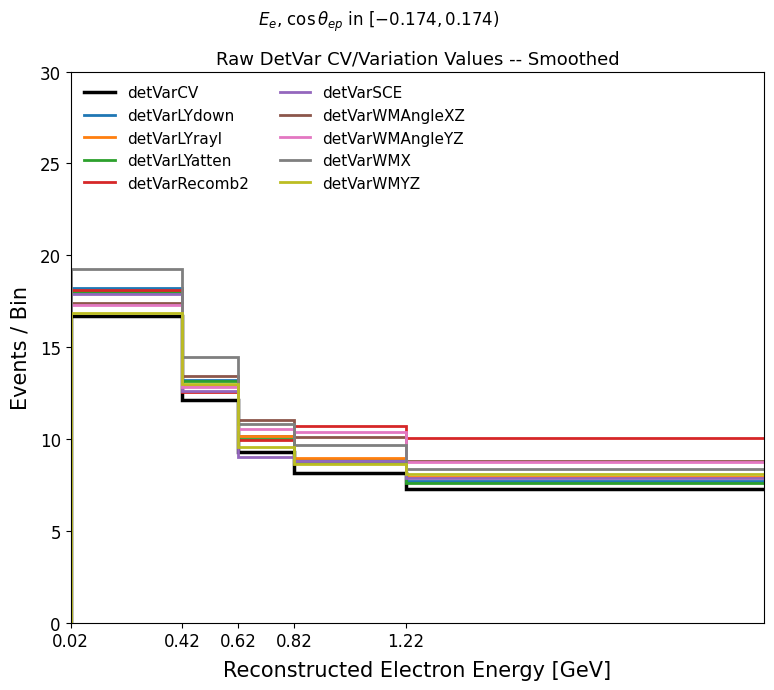

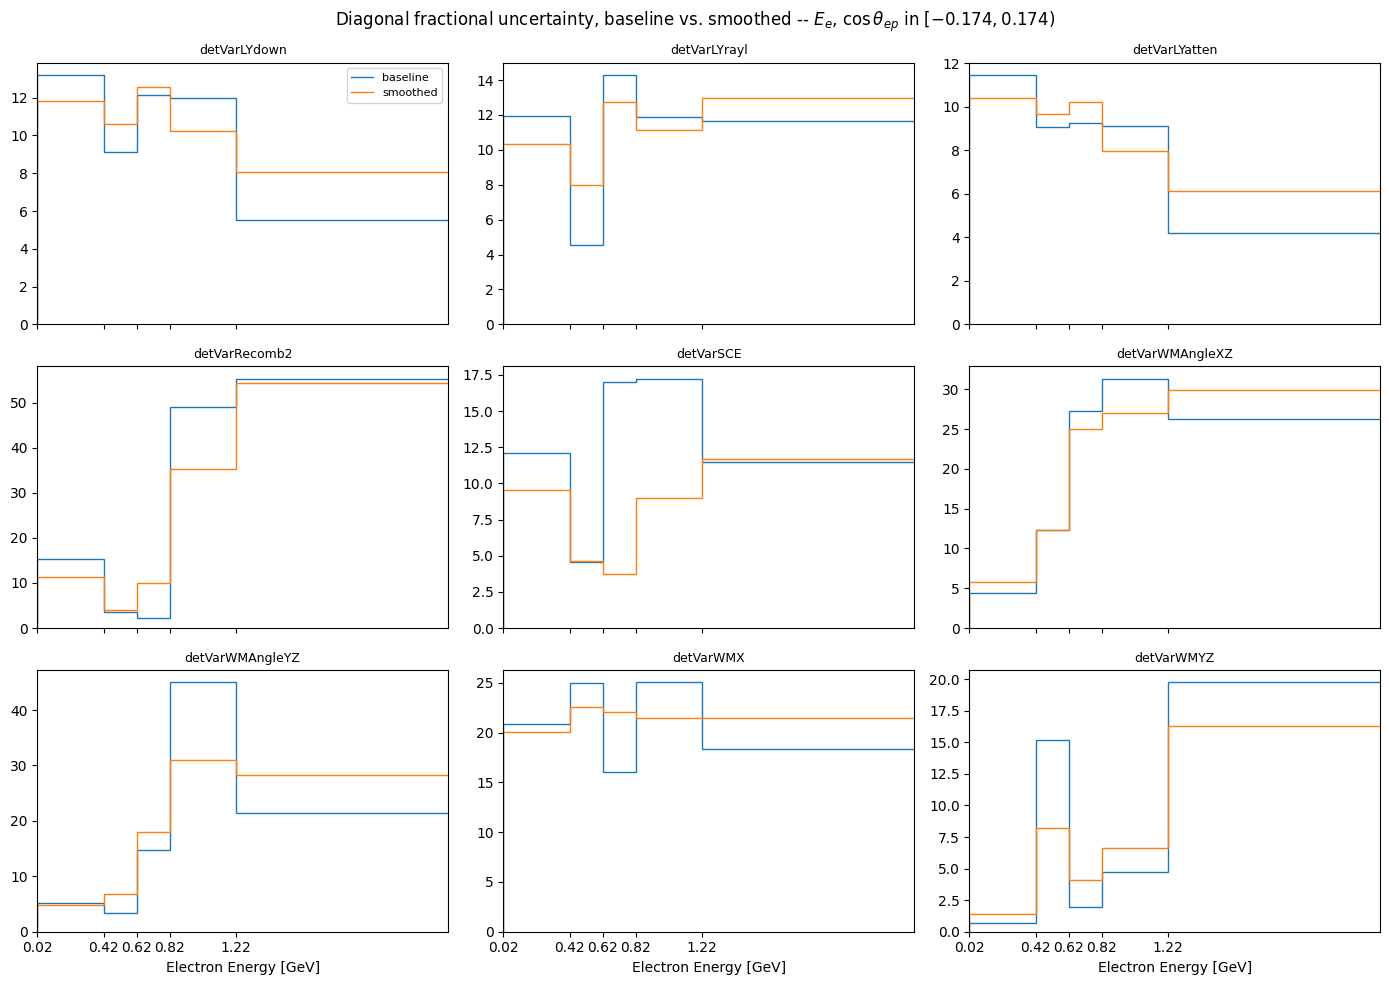

In [9]:
SLICE_LO, SLICE_HI = 10, 15  # E_e, cos(theta_e-p) in [-0.174, 0.174)

# Physical x-axis for the electron-energy plots below (everything except the
# matrices, which keep the categorical bin-index axis -- a heatmap doesn't
# have a single physical x value per row/column the way a line plot does).
E_E_BINS = [0.02, 0.42, 0.62, 0.82, 1.22, 7.00]
E_E_XLOW = E_E_BINS[0]
E_E_XHIGH = 2.5  # last bin runs to 7 GeV but there's nothing to see past here
E_E_XLABEL = "Electron Energy [GeV]"
E_E_XTICKS = [0.02, 0.42, 0.62, 0.82, 1.22]


def slice_axis_labels(lo, hi):
    """Short per-bin range strings for just this slice's active variable
    (drops the repeated '@ outer variable' part, since it's constant across
    the slice) -- feeds bin_edges_from_ranges() to get edge-position ticks
    for plot_slice_matrices."""
    return [re.sub(r"^[A-Za-z_]+ \(GeV\)", "", clean_label(bin_labels[i]).split(" @ ")[0])
            for i in range(lo, hi)]


def plot_slice_systematics(lo, hi, title=""):
    """Fractional uncertainty (diagonal), baseline state -- two panels, each
    auto-scaled to its own content: systematic categories on the left,
    statistical components (MC/EXT/NuMI) on the right. Split out because
    NuMI statistics dwarfs every systematic in this slice (300%+) and made
    the systematics illegible sharing one axis.

    Dirt is included as computed even though dirtNorm is currently
    misconfigured as MCFullCorr (100% on the *total* prediction) rather than
    MCFullCorrCategory (100% on just the dirt component) -- flagged, kept in
    pending a check with a colleague."""
    systematic_categories = [
        ("PredTotal", "Total", dict(color="black", linewidth=2)),
        ("flux", "Flux", dict(linewidth=2)),
        ("xsec_total", "Cross Section", dict(linewidth=2)),
        ("reint", "Particle Re-Interactions", dict(linewidth=2)),
        ("detVar_total", "Detector Response", dict(linewidth=2)),
        ("POT", "POT Counting", dict(linewidth=2)),
        ("numTargets", "Target Material", dict(linewidth=2)),
        # ("dirtNorm", "Dirt", dict(linewidth=2)),
    ]
    stat_categories = [
        ("MCstats", "MC Statistics", dict(linewidth=2)),
        ("EXTstats", "EXT Statistics", dict(linewidth=2)),
        ("BNBstats", "NuMI Statistics", dict(linewidth=2)),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    for ax, categories, panel_title in (
        (axes[0], systematic_categories, "Systematics"),
        (axes[1], stat_categories, "Statistics"),
    ):
        for key, label, style in categories:
            cov = f[f"{key}_cov_baseline"].values()[lo:hi, lo:hi]
            frac = np.sqrt(np.clip(np.diag(cov), 0, None)) / pred[lo:hi]
            ax.stairs(frac, E_E_BINS, label=label, **style)

        ax.set_xticks(E_E_XTICKS)
        ax.tick_params(axis="both", labelsize=12)
        ax.set_xlabel("Reconstructed " + E_E_XLABEL, fontsize=15, labelpad=7)
        ax.set_ylabel("Fractional Uncertainty", fontsize=15, labelpad=7)
        ax.set_xlim(E_E_XLOW, E_E_XHIGH)
        ax.set_title(panel_title, fontsize=13)
        ax.legend(fontsize=11, frameon=False, loc="upper left", ncol=1)

    fig.suptitle(f"Systematics Breakdown{title}")
    fig.tight_layout()
    return fig, axes


def plot_slice_matrices(name, lo, hi, title=""):
    """Cov/corr, baseline+smoothed, 2x2 grid, restricted to one slice.
    Axis ticks are the bin *edges* (physical values), not a range string
    centered on each bin."""
    edges = bin_edges_from_ranges(slice_axis_labels(lo, hi))
    edge_pos = np.arange(len(edges)) - 0.5
    edge_lbl = [format_edge(v) for v in edges]

    cov_before = f[f"{name}_cov_baseline"].values()[lo:hi, lo:hi]
    cov_after  = f[f"{name}_cov_smoothed"].values()[lo:hi, lo:hi]
    corr_before = f[f"{name}_corr_baseline"].values()[lo:hi, lo:hi]
    corr_after  = f[f"{name}_corr_smoothed"].values()[lo:hi, lo:hi]
    cov_scale = max(np.abs(cov_before).max(), np.abs(cov_after).max()) or 1.

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    panels = [
        (axes[0, 0], cov_before, f"{name} Covariance -- Baseline", -cov_scale, cov_scale),
        (axes[0, 1], cov_after,  f"{name} Covariance -- Smoothed", -cov_scale, cov_scale),
        (axes[1, 0], corr_before, f"{name} Correlation -- Baseline", -1., 1.),
        (axes[1, 1], corr_after,  f"{name} Correlation -- Smoothed", -1., 1.),
    ]
    for ax, vals, panel_title, vmin, vmax in panels:
        im = ax.imshow(vals, cmap="PiYG", vmin=vmin, vmax=vmax, origin="lower")
        ax.set_title(panel_title, fontsize=10)
        ax.set_xticks(edge_pos); ax.set_xticklabels(edge_lbl, fontsize=8, ha="right")
        ax.set_yticks(edge_pos); ax.set_yticklabels(edge_lbl, fontsize=8)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title.lstrip(" -"))
    fig.tight_layout()
    return fig, axes


def plot_slice_raw_detvars(lo, hi, state, title=""):
    """Raw CV + 9 individual DetVar values (not derived uncertainty), one
    state at a time ('unsmoothed' or 'smoothed') -- call twice for the two
    separate before/after plots. Styled to match plot_slice_systematics
    (fonts, frameless legend, LaTeX-ready suptitle)."""
    fig, ax = plt.subplots(figsize=(8, 7))
    cv = f[f"detVarCV_raw_{state}"].values()[lo:hi]
    ax.stairs(cv, E_E_BINS, label="detVarCV", color="black", linewidth=2.5)
    for name in systematics:
        if name in ("detVar_total",):
            continue
        key = f"{name}_raw_{state}"
        if key not in f:
            continue
        vals = f[key].values()[lo:hi]
        ax.stairs(vals, E_E_BINS, label=name, linewidth=2)

    ax.set_xticks(E_E_XTICKS)
    ax.tick_params(axis="both", labelsize=12)
    ax.set_xlabel("Reconstructed " + E_E_XLABEL, fontsize=15, labelpad=7)
    ax.set_ylabel("Events / Bin", fontsize=15, labelpad=7)
    ax.set_xlim(E_E_XLOW, E_E_XHIGH)
    ax.set_title(f"Raw DetVar CV/Variation Values -- {state.capitalize()}", fontsize=13)
    ax.legend(fontsize=11, frameon=False, loc="upper left", ncol=2)
    fig.suptitle(title.lstrip(" -"))
    fig.tight_layout()
    return fig, ax


def plot_slice_diagonal_grid(lo, hi, title=""):
    """Diagonal fractional uncertainty, baseline vs smoothed, one small
    panel per individual DetVar."""
    detvars = [n for n in systematics if n != "detVar_total"]
    fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True)
    for ax, name in zip(axes.flat, detvars):
        cov_b = f[f"{name}_cov_baseline"].values()[lo:hi, lo:hi]
        cov_s = f[f"{name}_cov_smoothed"].values()[lo:hi, lo:hi]
        frac_b = np.sqrt(np.clip(np.diag(cov_b), 0, None)) / pred[lo:hi]
        frac_s = np.sqrt(np.clip(np.diag(cov_s), 0, None)) / pred[lo:hi]
        ax.stairs(frac_b * 100, E_E_BINS, label="baseline")
        ax.stairs(frac_s * 100, E_E_BINS, label="smoothed")
        ax.set_title(name, fontsize=9)
        ax.set_xlim(E_E_XLOW, E_E_XHIGH)
        ax.set_xticks(E_E_XTICKS)
    axes.flat[0].legend(fontsize=8)
    for ax in axes[-1]:
        ax.set_xlabel(E_E_XLABEL)
    fig.suptitle(f"Diagonal fractional uncertainty, baseline vs. smoothed{title}")
    fig.tight_layout()
    return fig, axes


slice_title = r" -- $E_e$, $\cos{\theta_{ep}}$ in $[-0.174, 0.174)$"

fig, axes = plot_slice_systematics(SLICE_LO, SLICE_HI, title=slice_title)
axes[0].set_ylim(0, 2)  # manually raised max on the Systematics (left) panel
plt.savefig("slice_systematics.pdf", dpi=300, bbox_inches="tight")
plt.show()

plot_slice_matrices("detVar_total", SLICE_LO, SLICE_HI, title=f"detVar_total{slice_title}")
plt.savefig("slice_matrices.pdf", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plot_slice_raw_detvars(SLICE_LO, SLICE_HI, "unsmoothed", title=slice_title)
ax.set_ylim(0, 30)
plt.savefig("detvars_raw.pdf", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plot_slice_raw_detvars(SLICE_LO, SLICE_HI, "smoothed", title=slice_title)
ax.set_ylim(0, 30)
plt.savefig("detvars_smoothed.pdf", dpi=300, bbox_inches="tight")
plt.show()

plot_slice_diagonal_grid(SLICE_LO, SLICE_HI, title=slice_title)
plt.savefig("slice_diagonal.pdf", dpi=300, bbox_inches="tight")
plt.show()